[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab5-Comp-Mod/notebooks/08-cybernetics-of-wound-healing.ipynb)

# 08 — Cybernetics of Wound Healing

**BMED365 – Computational Medicine (Lab 5)**

_Arvid Lundervold w/ Claude (Anthropic) — 2026-02-14_<br>
_Updated: 2026-02-19_ (Cursor 2.5.17 with Claude Opus 4.6) <br>
_Updated: 2026-02-20_  (Cursor 2.5.20 with Claude Opus 4.6) - saved notebook to .pdf<br>
_Updated: 2026-02-28_  (Ubuntu 24.04, Cursor 2.5.26 with Claude Opus 4.6) - Testing

---

## 1. Motivation & Learning Objectives

### Why study wound healing through the lens of cybernetics?

Wound healing is one of the most fundamental processes in biology. Every multicellular organism — from fruit flies to humans — must be able to repair damaged tissue to survive. A small skin cut, a surgical incision, a chronic diabetic ulcer, and a battlefield burn wound all activate variants of the same ancient repair machinery.

What makes wound healing particularly fascinating from a **computational medicine** perspective is that it is not a simple, linear cascade. Instead, it is a **feedback control system** of extraordinary complexity: inflammatory cells detect damage and recruit repair cells; repair cells secrete growth factors that accelerate their own proliferation; and anti-inflammatory signals eventually shut down the process to prevent fibrosis. When these feedback loops work correctly, wounds heal cleanly in days to weeks. When they malfunction, the result can be **chronic non-healing wounds** (affecting ~2% of the population in developed countries) or **excessive scarring** (keloids, hypertrophic scars).

**Cybernetics** — the science of control and communication in living systems and machines — provides the conceptual framework to understand, model, and ultimately *intervene* in these feedback loops. By treating wound healing as a dynamical system with sensors, controllers, and actuators, we can:
- Predict whether a wound will heal or become chronic
- Design **bioelectronic devices** that monitor wounds and deliver targeted therapy
- Engineer **synthetic biology controllers** (e.g., bacterial circuits) that autonomously regulate the healing process

### What you will learn

In this notebook you will:

1. **Understand** the biology of wound healing — the four overlapping phases and the cell types involved
2. **Appreciate** the historical context — from ancient wound care to modern cybernetic medicine
3. **Define** key concepts — cybernetics, feedback loops, negative and positive feedback, homeostasis, and control theory
4. **Formulate** mathematical models of wound healing as coupled ODEs with feedback structure
5. **Implement** and simulate these models in Python
6. **Visualize** wound closure dynamics, phase portraits, and parameter sensitivity
7. **Explore** clinical implications — chronic wounds, bioelectronic interventions, and the future of smart wound care

## 2. Historical Context: From Ancient Wound Care to Cybernetic Medicine

### A brief history of wound healing

Wound care is among the oldest medical practices. The understanding of wound healing has evolved dramatically over millennia:

| Year / Era | Milestone | Key Figures |
|------|-----------|-----------|
| ~1600 BCE | Edwin Smith Papyrus — earliest known surgical text; describes wound closure with sutures and adhesive strips | Ancient Egyptian physicians |
| ~400 BCE | Hippocratic writings distinguish healing by "first intention" (clean closure) vs. "second intention" (open granulation) | **Hippocrates** |
| ~130–200 CE | Galen's theory of "laudable pus" — believed suppuration was necessary for healing (persisted for 1500 years!) | **Galen** of Pergamon |
| 1546 | First challenge to Galen: Paré advocates gentle wound care over cauterization | Ambroise **Paré** |
| 1858 | Virchow establishes cellular pathology — inflammation is a cellular response | Rudolf **Virchow** |
| 1867 | Lister introduces antiseptic surgery; wound infections plummet | Joseph **Lister** |
| 1882 | Metchnikoff discovers phagocytes — immune cells that engulf debris and bacteria | Élie **Metchnikoff** (Nobel 1908) |
| 1948 | Norbert Wiener publishes *Cybernetics* — the science of feedback and control in animals and machines | Norbert **Wiener** |
| 1962 | Winter demonstrates that moist wound environments heal faster than dry — birth of modern wound care | George **Winter** |
| 1986 | Discovery of platelet-derived growth factor (PDGF) role in wound healing | Ross, Raines, Bowen-Pope |
| 2002 | First computational models of wound healing as a dynamical system | Sherratt, Murray, and others |
| 2019 | Bacterial controller-aided wound healing (synthetic biology IFFL circuits) | Pedersen et al. (bioRxiv) |
| 2021 | Feedback control architecture for bioelectronic wound healing devices | Selberg et al. (*J. R. Soc. Interface*) |

### The cybernetics connection

In 1948, mathematician **Norbert Wiener** published his seminal book *Cybernetics: or Control and Communication in the Animal and the Machine*. Wiener argued that the same mathematical principles govern feedback regulation in engineering systems (thermostats, autopilots) and in biological organisms (homeostasis, reflexes, wound repair).

The word **cybernetics** comes from the Greek *κυβερνήτης* (*kybernētēs*), meaning "helmsman" or "governor" — the person who steers a ship by constantly adjusting the rudder based on feedback from the ship's course. This is precisely what happens in wound healing: the body constantly monitors tissue damage, adjusts its inflammatory and repair responses, and steers the wound toward closure.

> *"The nervous system and the automatic machine are fundamentally alike in that they are devices which make decisions on the basis of decisions they have made in the past."* — Norbert Wiener, *Cybernetics* (1948)

### Key references

- Selberg et al. (2021). [A feedback control architecture for bioelectronic devices with applications to wound healing](https://royalsocietypublishing.org/doi/10.1098/rsif.2021.0497). *J. R. Soc. Interface* 18: 20210497.
- Jorgensen et al. (2017). [Wound healing as an electromechanical feedback control system](https://ieeexplore.ieee.org/document/8191999). *IEEE EMBC*.
- Pedersen et al. (2019). [Bacterial Controller Aided Wound Healing](https://www.biorxiv.org/content/10.1101/659714v2). *bioRxiv*.

In [1]:
# --- Colab setup ---
import sys
if 'google.colab' in sys.modules:
    %pip install -q ipywidgets
    %matplotlib inline
    import urllib.request, os
    os.makedirs('../assets', exist_ok=True)
    _base = 'https://raw.githubusercontent.com/arvidl/BMED365-2026/main/Lab5-Comp-Mod/assets/'
    for f in ['wound-healing-phases.png']:
        if not os.path.exists(f'../assets/{f}'):
            urllib.request.urlretrieve(_base + f, f'../assets/{f}')
else:
    %matplotlib inline

In [6]:
from IPython.display import display, HTML

display(HTML('''
<figure style="text-align:center; margin: 20px auto; max-width:900px;">
<img src="../assets/wound-healing-phases.png"
     alt="Wound healing phases" width="800" />
<figcaption style="font-size:0.9em; color:#555; margin-top:8px;">
<b>Figure 1.</b> Overview of the overlapping phases of wound healing — hemostasis, inflammation,
proliferation, and remodeling — on a logarithmic time scale. Each phase involves distinct cell
populations and signaling molecules that interact through feedback loops.<br/>
<i>Source: Mikael Häggström / Wikimedia Commons (public domain).</i>
</figcaption>
</figure>
'''))

## 3. Biological Background: The Four Phases of Wound Healing

### What is wound healing?

**Wound healing** is the biological process by which the body repairs damaged tissue. In skin wounds — the most studied type — healing involves a tightly orchestrated sequence of cellular and molecular events that restore the barrier function and structural integrity of the tissue.

### Definitions

Before diving deeper, let us define some key terms:

| Term | Definition |
|------|------------|
| **Wound** | A disruption of normal tissue architecture caused by injury (mechanical, thermal, chemical, or biological) |
| **Acute wound** | A wound that progresses through the normal phases of healing in a timely and orderly manner (typically heals within 2–4 weeks) |
| **Chronic wound** | A wound that fails to proceed through the normal healing phases in an orderly and timely fashion; often stalled in the inflammatory phase (>4–6 weeks without significant healing) |
| **Hemostasis** | The process of stopping bleeding through vasoconstriction and clot formation |
| **Inflammation** | The body's protective response involving immune cells that clear debris and fight infection |
| **Proliferation** | The phase of active tissue repair: new blood vessels (angiogenesis), new connective tissue (granulation), and new skin (re-epithelialization) |
| **Remodeling** | The final phase where collagen is reorganized and the tissue matures (can last months to years) |
| **Fibroblast** | The primary cell responsible for synthesizing collagen and extracellular matrix during repair |
| **Macrophage** | An immune cell that phagocytoses debris and secretes growth factors to coordinate healing |
| **Growth factor** | A signaling protein (e.g., PDGF, TGF-β, VEGF) that regulates cell growth, proliferation, and differentiation |

### The four overlapping phases

Wound healing proceeds through four overlapping phases, each dominated by different cell types and signaling molecules:

#### Phase 1: Hemostasis (seconds to hours)
- **Trigger**: Tissue damage exposes blood to collagen and tissue factor
- **Events**: Vasoconstriction → platelet aggregation → fibrin clot formation
- **Key players**: Platelets, fibrin, thrombin
- **Feedback**: Platelets release **PDGF** and **TGF-β**, which recruit inflammatory cells — initiating the next phase

#### Phase 2: Inflammation (hours to days)
- **Trigger**: Damage-associated molecular patterns (DAMPs) and platelet-derived signals
- **Events**: Neutrophils arrive first (within hours) to kill bacteria; macrophages follow (24–48 hours) to phagocytose debris and secrete growth factors
- **Key players**: Neutrophils, macrophages, cytokines (IL-1, IL-6, TNF-α)
- **Feedback**: Macrophages secrete factors that recruit fibroblasts and promote angiogenesis — transitioning to proliferation. Anti-inflammatory signals (IL-10, TGF-β) eventually resolve inflammation — a **negative feedback** loop

#### Phase 3: Proliferation (days to weeks)
- **Trigger**: Growth factors from macrophages and platelets
- **Events**: Fibroblast migration and proliferation → collagen synthesis → angiogenesis (new blood vessel formation) → re-epithelialization (keratinocyte migration)
- **Key players**: Fibroblasts, endothelial cells, keratinocytes, VEGF, FGF
- **Feedback**: As the wound fills with granulation tissue, contact inhibition and reduced hypoxia signals slow down proliferation — another **negative feedback** loop

#### Phase 4: Remodeling (weeks to years)
- **Trigger**: Completion of granulation tissue
- **Events**: Type III collagen is gradually replaced by stronger type I collagen; wound contracts; scar matures
- **Key players**: Fibroblasts (now myofibroblasts), matrix metalloproteinases (MMPs)
- **Feedback**: The balance between MMP activity (breakdown) and collagen synthesis (buildup) determines scar quality. Dysregulation leads to keloids (excess) or chronic wounds (insufficient)

> **Key insight**: Each phase *feeds forward* into the next, while also containing *negative feedback* loops that self-limit the response. This interplay of positive (amplifying) and negative (damping) feedback is what makes wound healing a **cybernetic** system.

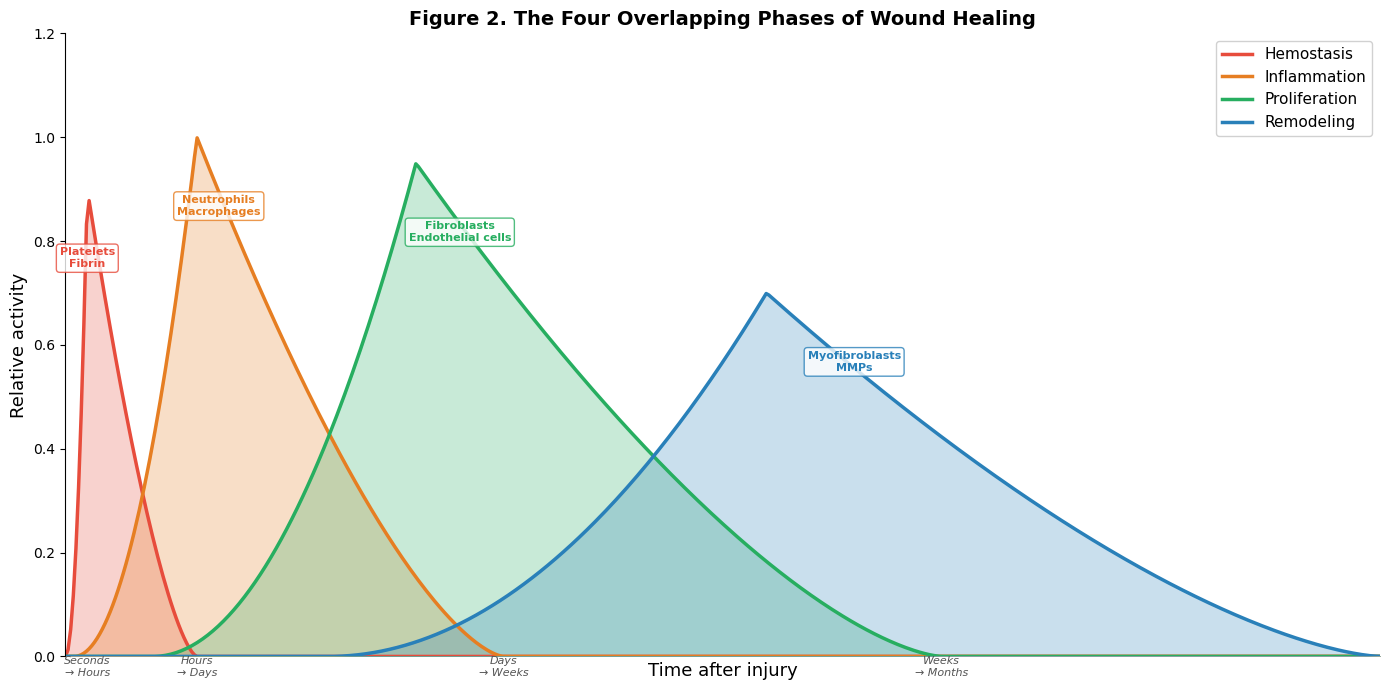

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
np.random.seed(42)


# --- Programmatic illustration: The Four Phases of Wound Healing ---

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 30)
ax.set_ylim(0, 1.2)
ax.set_xlabel('Time after injury', fontsize=13)
ax.set_ylabel('Relative activity', fontsize=13)
ax.set_title('Figure 2. The Four Overlapping Phases of Wound Healing', fontsize=14, fontweight='bold')

t = np.linspace(0, 30, 500)

def phase_curve(t, t_start, t_peak, t_end, amplitude=1.0):
    """Asymmetric bell curve for a healing phase."""
    y = np.zeros_like(t)
    rise = (t >= t_start) & (t <= t_peak)
    fall = (t > t_peak) & (t <= t_end)
    if np.any(rise):
        y[rise] = amplitude * ((t[rise] - t_start) / (t_peak - t_start)) ** 2
    if np.any(fall):
        y[fall] = amplitude * ((t_end - t[fall]) / (t_end - t_peak)) ** 1.5
    return y

phases = [
    {'name': 'Hemostasis',     'color': '#e74c3c', 't_start': 0,  't_peak': 0.5, 't_end': 3,  'amp': 0.9},
    {'name': 'Inflammation',   'color': '#e67e22', 't_start': 0.2,'t_peak': 3,   't_end': 10, 'amp': 1.0},
    {'name': 'Proliferation',  'color': '#27ae60', 't_start': 2,  't_peak': 8,   't_end': 20, 'amp': 0.95},
    {'name': 'Remodeling',     'color': '#2980b9', 't_start': 6,  't_peak': 16,  't_end': 30, 'amp': 0.7},
]

for p in phases:
    y = phase_curve(t, p['t_start'], p['t_peak'], p['t_end'], p['amp'])
    ax.fill_between(t, y, alpha=0.25, color=p['color'])
    ax.plot(t, y, color=p['color'], linewidth=2.5, label=p['name'])

# Time annotations
time_labels = [
    (0.5, -0.08, 'Seconds\n→ Hours'),
    (3, -0.08, 'Hours\n→ Days'),
    (10, -0.08, 'Days\n→ Weeks'),
    (20, -0.08, 'Weeks\n→ Months'),
]
for x, y_pos, label in time_labels:
    ax.annotate(label, xy=(x, 0), fontsize=8, ha='center', va='top',
                color='#555', style='italic')

# Key cell types
cell_annotations = [
    (0.5, 0.75, 'Platelets\nFibrin', '#e74c3c'),
    (3.5, 0.85, 'Neutrophils\nMacrophages', '#e67e22'),
    (9, 0.80, 'Fibroblasts\nEndothelial cells', '#27ae60'),
    (18, 0.55, 'Myofibroblasts\nMMPs', '#2980b9'),
]
for x, y_pos, label, color in cell_annotations:
    ax.annotate(label, xy=(x, y_pos), fontsize=8, ha='center',
                color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=color, alpha=0.8))

ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.tight_layout()
plt.show()

### Check Your Understanding: Wound Healing Biology

**Q1.** A patient has a clean surgical incision that is closed with sutures. Which type of healing is this — "first intention" or "second intention"? What is the difference?

<details>
<summary>Click to reveal answer</summary>

This is **healing by first intention** (also called *primary intention*). The wound edges are brought together (approximated) by sutures, staples, or adhesive strips, so the gap to fill is minimal.

- **First intention**: Clean, closed wound → minimal granulation tissue → thin scar → fast healing (days)
- **Second intention**: Open wound (e.g., ulcer, burn) → must fill from the bottom up with granulation tissue → larger scar → slow healing (weeks to months)

There is also **third intention** (delayed primary closure): the wound is initially left open (e.g., to allow infection to clear) and then closed surgically later.

</details>

---

**Q2.** Why is the inflammatory phase *essential* for healing, even though inflammation is often viewed as harmful?

<details>
<summary>Click to reveal answer</summary>

The inflammatory phase serves several critical functions:

1. **Infection control**: Neutrophils kill bacteria that have entered through the wound
2. **Debris clearance**: Macrophages phagocytose dead cells, damaged extracellular matrix, and foreign material
3. **Signal relay**: Macrophages secrete growth factors (PDGF, TGF-β, VEGF) that are *essential* for recruiting fibroblasts and initiating the proliferative phase
4. **Coordination**: Cytokines coordinate the spatial and temporal progression of healing

Without inflammation, wounds cannot heal. Experiments show that depleting macrophages severely impairs wound repair. However, *excessive* or *prolonged* inflammation is indeed harmful — it is a hallmark of chronic wounds. The key is the **negative feedback** that resolves inflammation at the right time.

</details>

---

**Q3.** A diabetic patient has a foot ulcer that has not healed in 8 weeks. In which phase of wound healing is this wound most likely "stuck"? Why might diabetes impair healing?

<details>
<summary>Click to reveal answer</summary>

Chronic diabetic wounds are typically stalled in the **inflammatory phase**. The transition from inflammation to proliferation fails.

Diabetes impairs healing through multiple mechanisms:
- **Hyperglycemia** damages blood vessels (microangiopathy) → reduced blood flow and oxygen delivery
- **Neuropathy** → patient doesn't feel the wound → continued trauma
- **Impaired immune function** → neutrophils and macrophages function poorly → prolonged, unresolved inflammation
- **Reduced growth factor production** → fibroblasts are not adequately recruited
- **Elevated MMPs** → excessive matrix degradation → granulation tissue is broken down faster than it is formed

In cybernetic terms, the **negative feedback loop** that should resolve inflammation is broken, and the **positive feedback** that amplifies the inflammatory response dominates, creating a self-sustaining pathological state.

</details>

## 4. Cybernetics: Definitions and Concepts

### What is cybernetics?

**Cybernetics** is the interdisciplinary study of regulatory systems — their structure, constraints, and possibilities. Founded by **Norbert Wiener** in 1948, cybernetics applies to any system (biological, mechanical, social) that uses **feedback** to regulate its behavior.

### Key definitions from control theory

| Concept | Definition | Wound Healing Example |
|---------|-----------|----------------------|
| **System** | A collection of interacting components that together produce behavior not achievable by any component alone | The wound healing cascade (platelets + immune cells + fibroblasts + signals) |
| **State variable** | A measurable quantity that describes the system's current condition | Wound area $A(t)$, inflammatory cell count $I(t)$, fibroblast density $F(t)$ |
| **Feedback** | Information about the output of a system that is fed back to influence its input | Wound size signals to macrophages → macrophages promote repair → wound shrinks → signal decreases |
| **Negative feedback** | Feedback that opposes change, promoting stability and homeostasis | Wound → inflammation → repair → wound closure → inflammation stops |
| **Positive feedback** | Feedback that amplifies change, promoting growth or runaway behavior | Platelet activation → recruits more platelets → rapid clot formation |
| **Setpoint** | The target value that the system tries to maintain or reach | Intact skin (wound area = 0) |
| **Controller** | The component that processes the error signal and determines the response | Macrophages (sense damage, secrete growth factors to drive repair) |
| **Actuator** | The component that carries out the corrective action | Fibroblasts (synthesize collagen to fill the wound) |
| **Sensor** | The component that measures the current state | Damage-associated molecular patterns (DAMPs), oxygen sensors, mechanical tension |
| **Error signal** | The difference between the setpoint and the current state | The extent of remaining tissue damage (wound area > 0) |
| **Homeostasis** | The maintenance of a stable internal state through feedback regulation | Restoration of intact skin barrier after injury |

### The wound healing feedback loop

Wound healing can be conceptualized as a **negative feedback control system**:

```
  Setpoint: Intact skin (A = 0)
           │
           ▼
  ┌────────────────┐      Error = A(t) > 0      ┌────────────────┐
  │   COMPARATOR   │ ──────────────────────────▶ │   CONTROLLER   │
  │  (immune cells │                             │  (macrophages, │
  │   detect damage)│                             │   growth factors)│
  └────────────────┘                             └───────┬────────┘
           ▲                                             │
           │                                             ▼
  ┌────────────────┐                             ┌────────────────┐
  │     SENSOR     │                             │    ACTUATOR    │
  │  (DAMPs, O₂,   │◀──────────────────────────  │  (fibroblasts, │
  │   cytokines)   │     Wound closes (A ↓)      │   collagen)    │
  └────────────────┘                             └────────────────┘
```

When the wound is large, the error signal is strong → the controller activates repair strongly. As the wound closes, the error signal weakens → repair slows down. This is textbook **proportional negative feedback control**.

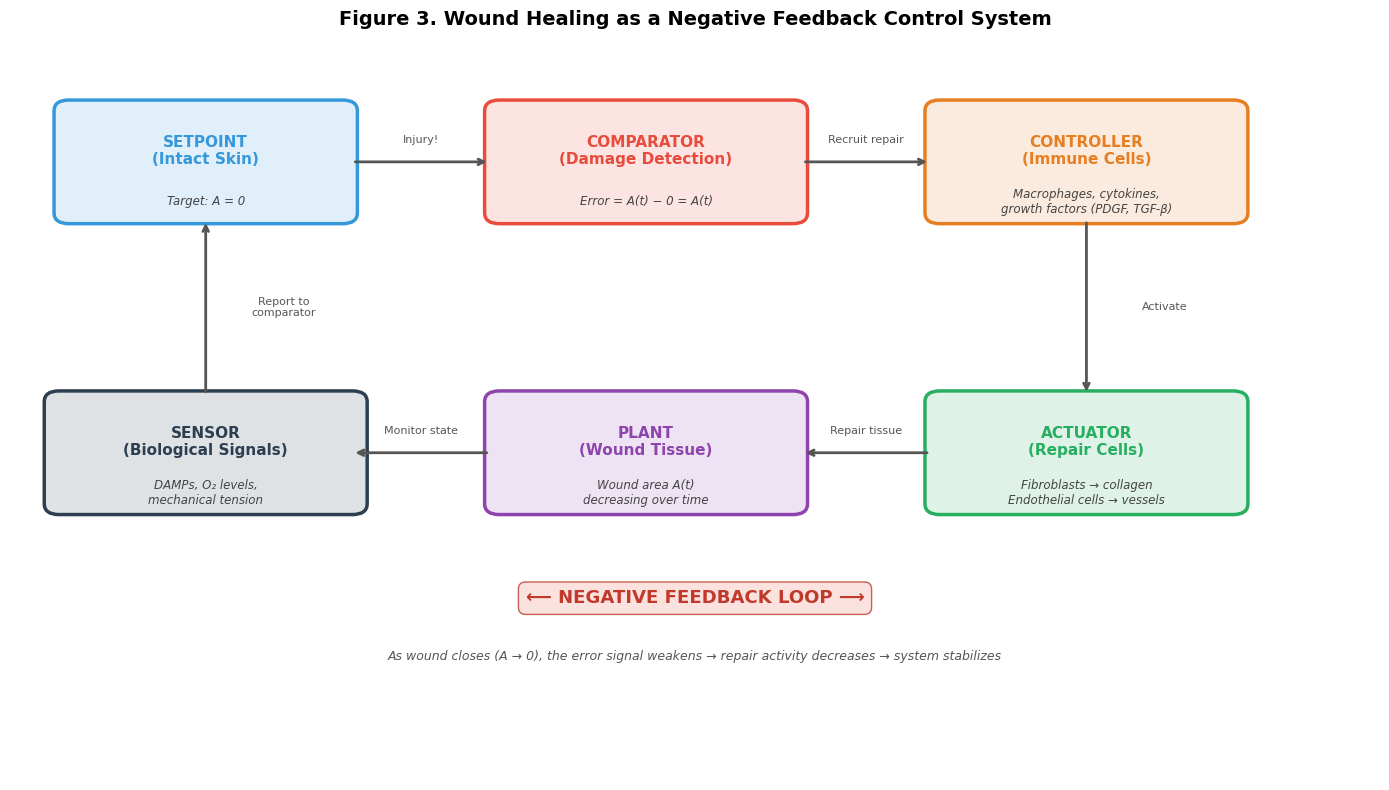

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# --- Programmatic illustration: Wound healing as a feedback control system ---

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Figure 3. Wound Healing as a Negative Feedback Control System',
             fontsize=14, fontweight='bold', pad=20)

box_style = dict(boxstyle='round,pad=0.5', linewidth=2)
font_title = dict(fontsize=11, fontweight='bold', ha='center', va='center')
font_detail = dict(fontsize=8.5, ha='center', va='center', style='italic', color='#444')

boxes = [
    {'label': 'SETPOINT\n(Intact Skin)', 'detail': 'Target: A = 0',
     'xy': (2, 8.5), 'color': '#3498db', 'w': 2.8, 'h': 1.4},
    {'label': 'COMPARATOR\n(Damage Detection)', 'detail': 'Error = A(t) − 0 = A(t)',
     'xy': (6.5, 8.5), 'color': '#e74c3c', 'w': 3.0, 'h': 1.4},
    {'label': 'CONTROLLER\n(Immune Cells)', 'detail': 'Macrophages, cytokines,\ngrowth factors (PDGF, TGF-β)',
     'xy': (11, 8.5), 'color': '#e67e22', 'w': 3.0, 'h': 1.4},
    {'label': 'ACTUATOR\n(Repair Cells)', 'detail': 'Fibroblasts → collagen\nEndothelial cells → vessels',
     'xy': (11, 4.5), 'color': '#27ae60', 'w': 3.0, 'h': 1.4},
    {'label': 'PLANT\n(Wound Tissue)', 'detail': 'Wound area A(t)\ndecreasing over time',
     'xy': (6.5, 4.5), 'color': '#8e44ad', 'w': 3.0, 'h': 1.4},
    {'label': 'SENSOR\n(Biological Signals)', 'detail': 'DAMPs, O₂ levels,\nmechanical tension',
     'xy': (2, 4.5), 'color': '#2c3e50', 'w': 3.0, 'h': 1.4},
]

for b in boxes:
    x, y = b['xy']
    w, h = b['w'], b['h']
    rect = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle='round,pad=0.15',
                          facecolor=b['color'], edgecolor='white',
                          alpha=0.15, linewidth=0)
    ax.add_patch(rect)
    rect2 = FancyBboxPatch((x - w/2, y - h/2), w, h,
                           boxstyle='round,pad=0.15',
                           facecolor='none', edgecolor=b['color'],
                           linewidth=2.5)
    ax.add_patch(rect2)
    ax.text(x, y + 0.15, b['label'], **font_title, color=b['color'])
    ax.text(x, y - 0.55, b['detail'], **font_detail)

# Arrows (top row: left to right; right side: down; bottom row: right to left; left side: up)
arrow_style = 'Simple,tail_width=1.5,head_width=10,head_length=8'
arrow_props = dict(arrowstyle=arrow_style, color='#555', lw=1.5)

arrows = [
    ((3.5, 8.5), (4.9, 8.5), 'Injury!'),
    ((8.1, 8.5), (9.4, 8.5), 'Recruit repair'),
    ((11, 7.7), (11, 5.3), 'Activate'),
    ((9.4, 4.5), (8.1, 4.5), 'Repair tissue'),
    ((4.9, 4.5), (3.5, 4.5), 'Monitor state'),
    ((2, 5.3), (2, 7.7), 'Report to\ncomparator'),
]

for (x1, y1), (x2, y2), label in arrows:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#555',
                                lw=2, connectionstyle='arc3,rad=0'))
    mx, my = (x1 + x2) / 2, (y1 + y2) / 2
    offset = (0, 0.3) if y1 == y2 else (0.8 if x1 == x2 else 0, 0)
    ax.text(mx + offset[0], my + offset[1], label,
            fontsize=8, ha='center', va='center', color='#555',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor='none', alpha=0.8))

# Negative feedback label
ax.text(7, 2.5, '⟵ NEGATIVE FEEDBACK LOOP ⟶',
        fontsize=13, ha='center', va='center', fontweight='bold',
        color='#c0392b',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fadbd8',
                  edgecolor='#c0392b', alpha=0.8))
ax.text(7, 1.7,
        'As wound closes (A → 0), the error signal weakens → repair activity decreases → system stabilizes',
        fontsize=9, ha='center', va='center', color='#555', style='italic')

plt.tight_layout()
plt.show()

### Check Your Understanding: Cybernetics Concepts

**Q4.** In the wound healing control loop above, what happens if the "sensor" component is impaired — for example, if the tissue cannot properly detect remaining damage?

<details>
<summary>Click to reveal answer</summary>

If the sensor is impaired (e.g., due to diabetic neuropathy or immunosuppression), the system cannot accurately assess the current wound state. This leads to:

1. **Insufficient error signal** → the controller (immune cells) does not activate repair strongly enough → **chronic wound** (under-healing)
2. Alternatively, a **false persistent error signal** → the controller keeps activating even after the wound has closed → **excessive scarring** (keloid, fibrosis)

In control theory terms, a broken sensor leads to **open-loop** behavior — the system acts without knowing its current state, which almost always leads to poor performance. This is analogous to a thermostat with a broken thermometer: it cannot regulate temperature properly.

</details>

---

**Q5.** Give an example of **positive feedback** in wound healing. Why doesn't it cause runaway behavior?

<details>
<summary>Click to reveal answer</summary>

**Platelet activation** during hemostasis is a classic positive feedback loop:
- Activated platelets release ADP and thromboxane A₂
- These molecules activate *more* platelets
- Which release *more* ADP and thromboxane
- → Rapid clot formation (explosive amplification)

This positive feedback doesn't cause runaway behavior because it is **bounded** by:
1. **Physical confinement** — the clot is localized to the wound site
2. **Anticoagulant factors** — antithrombin, protein C, and prostacyclin from intact endothelium limit clot spread
3. **Negative feedback override** — once hemostasis is achieved, the system transitions to inflammation, and different feedback loops take over

In engineering, this is called a **saturating positive feedback** — amplification occurs rapidly but is eventually capped. If these brakes fail, the result is pathological: **disseminated intravascular coagulation (DIC)**, a life-threatening condition.

</details>

---

**Q6.** How is the wound healing feedback system similar to — and different from — a household thermostat?

<details>
<summary>Click to reveal answer</summary>

**Similarities:**
- Both have a **setpoint** (thermostat: desired temperature; wound: intact skin)
- Both use **negative feedback** (thermostat: heater turns on when too cold, off when warm enough; wound: repair activates when damaged, stops when healed)
- Both have **sensors** (thermostat: thermometer; wound: DAMPs, cytokines)

**Differences:**
- A thermostat is a **simple bang-bang controller** (on/off); wound healing uses **proportional, graded** responses with multiple interacting feedback loops
- A thermostat operates continuously in a steady state; wound healing is a **transient process** that activates, completes its task, and then shuts down
- Wound healing involves **multiple cascading phases**, each with its own feedback structure — much more complex than a single-loop thermostat
- Wound healing has **spatial organization** (cells migrate, gradients form) — the thermostat typically does not

</details>

## 5. Scientific and Clinical Implications

Understanding wound healing as a cybernetic system has profound implications for both science and medicine:

### Chronic Wounds: A Global Health Challenge
- **Prevalence**: Chronic wounds affect ~8.2 million people in the US alone; global cost exceeds **$25 billion/year**
- **Types**: Diabetic foot ulcers, venous leg ulcers, pressure ulcers (bedsores), arterial ulcers
- **Cybernetic interpretation**: Chronic wounds are a **control system failure** — the negative feedback loop that resolves inflammation and promotes proliferation is broken. The wound is "stuck" in a pathological steady state (a **bistable trap**)
- **Implication**: Therapy must *restart* the feedback loop, not just address symptoms

### Bioelectronic Medicine: Smart Wound Care
- Endogenous **electric fields** (injury currents, ~100–200 mV/mm) guide cell migration during wound healing — a phenomenon called **galvanotaxis**
- **Bioelectronic devices** can sense wound parameters (pH, temperature, moisture, impedance) and deliver **closed-loop** electrical stimulation to promote healing
- Selberg et al. (2021) proposed a formal **feedback control architecture** for such devices, mapping wound healing onto standard control engineering diagrams

### Synthetic Biology: Bacterial Controllers
- Pedersen et al. (2019) engineered bacteria with an **incoherent feed-forward loop (IFFL)** — a genetic circuit that senses wound inflammation and releases anti-inflammatory molecules in a self-regulating manner
- This is a **biological controller** designed using control theory principles to achieve robust wound management

### Scarring and Fibrosis
- Excessive healing (the opposite of chronic wounds) leads to **hypertrophic scars** and **keloids**
- In internal organs, fibrosis (liver cirrhosis, pulmonary fibrosis, cardiac fibrosis) kills millions yearly
- The balance between pro- and anti-fibrotic feedback signals is the key therapeutic target

### Computational Modeling in Drug Development
- Mathematical models of wound healing are used to:
  - **Screen** drug candidates *in silico* before expensive clinical trials
  - **Optimize** dosing regimens for growth factors and anti-inflammatory agents
  - **Predict** patient-specific healing trajectories based on individual parameters (precision medicine)

### Regenerative Medicine
- Understanding why some organisms (e.g., axolotls, zebrafish) regenerate perfectly while humans scar has led to insights about the **evolution of feedback control** in wound repair
- Manipulating feedback loops may enable **scar-free healing** in humans — one of the grand challenges of regenerative medicine

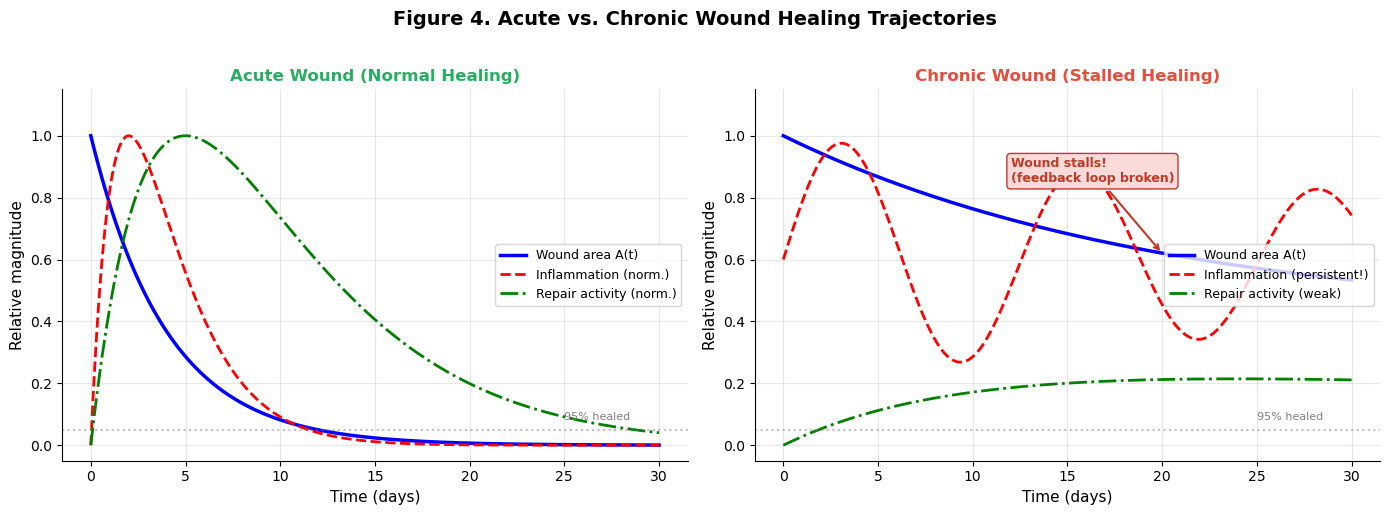

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

# --- Programmatic illustration: Acute vs Chronic Wound Dynamics ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

t = np.linspace(0, 30, 300)

# Acute wound: normal healing
A_acute = np.exp(-0.25 * t)
I_acute = 1.5 * t * np.exp(-0.5 * t)  # inflammation peaks then resolves
F_acute = 0.8 * t * np.exp(-0.2 * t)  # repair factor

ax = axes[0]
ax.plot(t, A_acute, 'b-', lw=2.5, label='Wound area A(t)')
ax.plot(t, I_acute / I_acute.max(), 'r--', lw=2, label='Inflammation (norm.)')
ax.plot(t, F_acute / F_acute.max(), 'g-.', lw=2, label='Repair activity (norm.)')
ax.axhline(y=0.05, color='gray', linestyle=':', alpha=0.5)
ax.text(25, 0.08, '95% healed', fontsize=8, color='gray')
ax.set_xlabel('Time (days)', fontsize=11)
ax.set_ylabel('Relative magnitude', fontsize=11)
ax.set_title('Acute Wound (Normal Healing)', fontsize=12, fontweight='bold', color='#27ae60')
ax.legend(fontsize=9, loc='center right')
ax.set_ylim(-0.05, 1.15)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Chronic wound: stalled healing
A_chronic = 0.4 + 0.6 * np.exp(-0.05 * t)  # stalls at ~40% remaining
I_chronic = 0.6 + 0.4 * np.sin(0.5 * t) * np.exp(-0.02 * t)  # persistent inflammation
F_chronic = 0.3 * (1 - np.exp(-0.1 * t)) * np.exp(-0.01 * t)  # weak repair

ax = axes[1]
ax.plot(t, A_chronic, 'b-', lw=2.5, label='Wound area A(t)')
ax.plot(t, I_chronic, 'r--', lw=2, label='Inflammation (persistent!)')
ax.plot(t, F_chronic, 'g-.', lw=2, label='Repair activity (weak)')
ax.axhline(y=0.05, color='gray', linestyle=':', alpha=0.5)
ax.text(25, 0.08, '95% healed', fontsize=8, color='gray')
ax.set_xlabel('Time (days)', fontsize=11)
ax.set_ylabel('Relative magnitude', fontsize=11)
ax.set_title('Chronic Wound (Stalled Healing)', fontsize=12, fontweight='bold', color='#e74c3c')
ax.legend(fontsize=9, loc='center right')
ax.set_ylim(-0.05, 1.15)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotations
axes[1].annotate('Wound stalls!\n(feedback loop broken)',
                 xy=(20, A_chronic[200]), xytext=(12, 0.85),
                 fontsize=9, color='#c0392b', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5),
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#fadbd8',
                           edgecolor='#c0392b'))

fig.suptitle('Figure 4. Acute vs. Chronic Wound Healing Trajectories',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Mathematical Formulation

### Model 1: Simple exponential wound closure

The simplest model of wound healing describes the wound area $A(t)$ as decaying exponentially:

$$\frac{dA}{dt} = -k \cdot A$$

where:
- $A(t)$ is the wound area at time $t$ (in cm²)
- $k > 0$ is the **healing rate constant** (in day⁻¹)

This has the exact solution $A(t) = A_0 \, e^{-kt}$, predicting exponential closure. While simple, this model captures the empirically observed fact that wounds tend to close faster when they are large and slower as they approach full closure.

**Limitations**: This model has no feedback structure — $k$ is constant and does not depend on the biological state of the wound.

### Model 2: Feedback-enhanced wound healing

A cybernetic extension introduces a **healing factor** $F(t)$ (representing the combined activity of fibroblasts, growth factors, and new vasculature) that is stimulated by the wound and feeds back to accelerate closure:

$$\frac{dA}{dt} = -k \cdot A \cdot (1 + \alpha F)$$

$$\frac{dF}{dt} = \beta A - \gamma F$$

where:
- $\alpha$ is the **feedback gain** — how strongly $F$ accelerates healing
- $\beta$ is the **wound-stimulated recruitment rate** — how strongly the wound drives production of $F$
- $\gamma$ is the **natural decay rate** of the healing factor

**Feedback structure analysis:**
- The $\beta A$ term in the $F$ equation means: "large wound → more healing factor produced" (feedforward from wound to repair)
- The $\alpha F$ term in the $A$ equation means: "more healing factor → faster wound closure" (feedback from repair to wound)
- As $A \to 0$: the stimulus for $F$ production vanishes → $F$ decays → the system shuts down
- This is a **self-terminating negative feedback loop** — exactly what we want biologically

### Model 3: Extended model with inflammatory dynamics

For a more realistic model, we add an explicit **inflammatory cell population** $I(t)$:

$$\frac{dA}{dt} = -k_1 \cdot A \cdot F + k_2 \cdot A \cdot I$$

$$\frac{dI}{dt} = \beta_I \cdot A - \gamma_I \cdot I - \delta \cdot I \cdot F$$

$$\frac{dF}{dt} = \beta_F \cdot I - \gamma_F \cdot F$$

Here:
- $k_1 \cdot A \cdot F$: repair by fibroblasts (reduces wound area)
- $k_2 \cdot A \cdot I$: tissue damage from excessive inflammation (increases wound area)
- $\delta \cdot I \cdot F$: anti-inflammatory effect — repair factors help resolve inflammation

This model can exhibit **bistability**: for some parameter values, there are two stable steady states — one where the wound heals (A → 0) and one where the wound persists (A → A*). This captures the clinical reality of **chronic wounds** that become trapped in a self-sustaining pathological state.

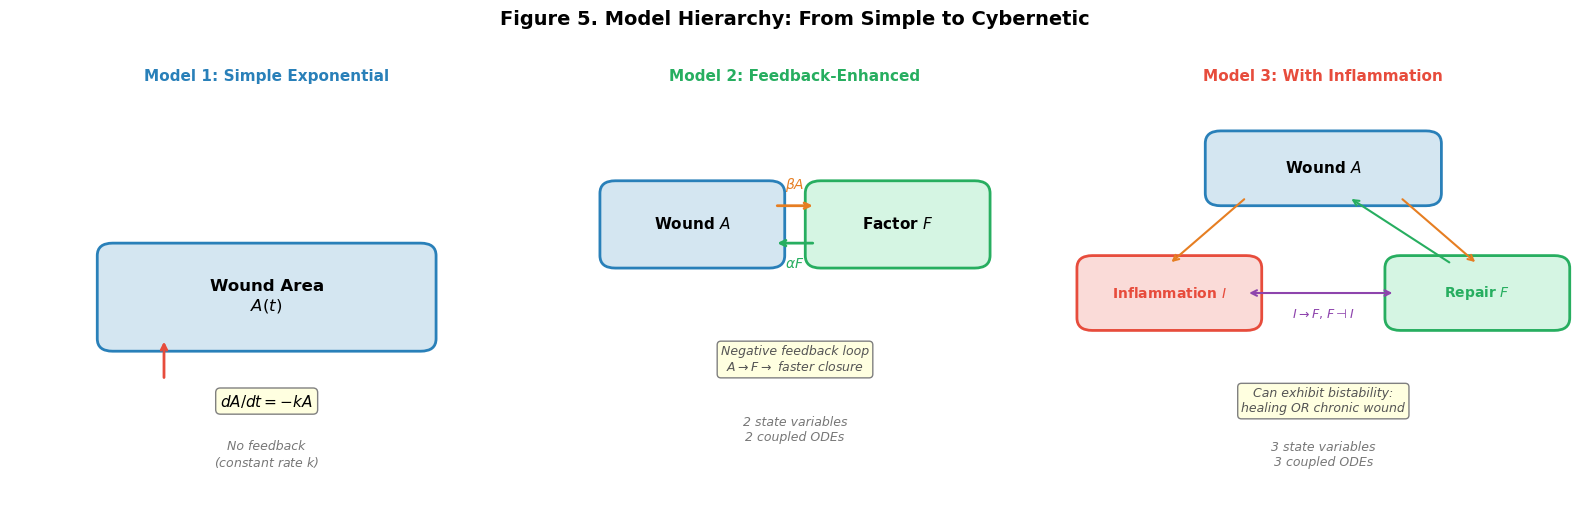

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# --- Programmatic illustration: Model hierarchy ---

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax in axes:
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

# Model 1: Simple exponential
ax = axes[0]
ax.set_title('Model 1: Simple Exponential', fontsize=11, fontweight='bold', color='#2980b9')
rect = FancyBboxPatch((2, 4), 6, 2, boxstyle='round,pad=0.3',
                       facecolor='#d4e6f1', edgecolor='#2980b9', linewidth=2)
ax.add_patch(rect)
ax.text(5, 5, 'Wound Area\n$A(t)$', fontsize=12, ha='center', va='center', fontweight='bold')
ax.annotate('', xy=(3, 4), xytext=(3, 3),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2))
ax.text(5, 2.5, '$dA/dt = -kA$', fontsize=11, ha='center', va='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))
ax.text(5, 1.2, 'No feedback\n(constant rate $k$)', fontsize=9, ha='center',
        va='center', color='#777', style='italic')

# Model 2: Feedback-enhanced
ax = axes[1]
ax.set_title('Model 2: Feedback-Enhanced', fontsize=11, fontweight='bold', color='#27ae60')
rect1 = FancyBboxPatch((1.5, 6), 3, 1.5, boxstyle='round,pad=0.3',
                        facecolor='#d4e6f1', edgecolor='#2980b9', linewidth=2)
rect2 = FancyBboxPatch((5.5, 6), 3, 1.5, boxstyle='round,pad=0.3',
                        facecolor='#d5f5e3', edgecolor='#27ae60', linewidth=2)
ax.add_patch(rect1)
ax.add_patch(rect2)
ax.text(3, 6.75, 'Wound $A$', fontsize=11, ha='center', va='center', fontweight='bold')
ax.text(7, 6.75, 'Factor $F$', fontsize=11, ha='center', va='center', fontweight='bold')

ax.annotate('', xy=(5.4, 7.2), xytext=(4.6, 7.2),
            arrowprops=dict(arrowstyle='->', color='#e67e22', lw=2))
ax.text(5, 7.6, '$\\beta A$', fontsize=10, ha='center', color='#e67e22')
ax.annotate('', xy=(4.6, 6.3), xytext=(5.4, 6.3),
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2))
ax.text(5, 5.7, '$\\alpha F$', fontsize=10, ha='center', color='#27ae60')

ax.text(5, 3.5, 'Negative feedback loop\n$A \\to F \\to$ faster closure', fontsize=9,
        ha='center', va='center', color='#555', style='italic',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))
ax.text(5, 1.8, '2 state variables\n2 coupled ODEs', fontsize=9, ha='center',
        va='center', color='#777', style='italic')

# Model 3: Extended with inflammation
ax = axes[2]
ax.set_title('Model 3: With Inflammation', fontsize=11, fontweight='bold', color='#e74c3c')
rect1 = FancyBboxPatch((3, 7.5), 4, 1.2, boxstyle='round,pad=0.3',
                        facecolor='#d4e6f1', edgecolor='#2980b9', linewidth=2)
rect2 = FancyBboxPatch((0.5, 4.5), 3, 1.2, boxstyle='round,pad=0.3',
                        facecolor='#fadbd8', edgecolor='#e74c3c', linewidth=2)
rect3 = FancyBboxPatch((6.5, 4.5), 3, 1.2, boxstyle='round,pad=0.3',
                        facecolor='#d5f5e3', edgecolor='#27ae60', linewidth=2)
ax.add_patch(rect1)
ax.add_patch(rect2)
ax.add_patch(rect3)
ax.text(5, 8.1, 'Wound $A$', fontsize=11, ha='center', va='center', fontweight='bold')
ax.text(2, 5.1, 'Inflammation $I$', fontsize=10, ha='center', va='center',
        fontweight='bold', color='#e74c3c')
ax.text(8, 5.1, 'Repair $F$', fontsize=10, ha='center', va='center',
        fontweight='bold', color='#27ae60')

# Arrows
ax.annotate('', xy=(2, 5.8), xytext=(3.5, 7.4),
            arrowprops=dict(arrowstyle='->', color='#e67e22', lw=1.5))
ax.annotate('', xy=(8, 5.8), xytext=(6.5, 7.4),
            arrowprops=dict(arrowstyle='->', color='#e67e22', lw=1.5))
ax.annotate('', xy=(5.5, 7.4), xytext=(7.5, 5.8),
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5))
ax.annotate('', xy=(3.5, 5.1), xytext=(6.4, 5.1),
            arrowprops=dict(arrowstyle='<->', color='#8e44ad', lw=1.5))

ax.text(5, 4.5, '$I \\to F$, $F \\dashv I$', fontsize=9, ha='center',
        color='#8e44ad')
ax.text(5, 2.5, 'Can exhibit bistability:\nhealing OR chronic wound',
        fontsize=9, ha='center', va='center', color='#555', style='italic',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray'))
ax.text(5, 1.2, '3 state variables\n3 coupled ODEs', fontsize=9, ha='center',
        va='center', color='#777', style='italic')

fig.suptitle('Figure 5. Model Hierarchy: From Simple to Cybernetic',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Check Your Understanding: Mathematical Models

**Q7.** In Model 2, what is the **steady state** of the system? (Hint: set both derivatives to zero and solve.)

<details>
<summary>Click to reveal answer</summary>

Setting $dA/dt = 0$ and $dF/dt = 0$:

From $dA/dt = -kA(1 + \alpha F) = 0$: either $A = 0$ or $F = -1/\alpha$ (unphysical since $F \geq 0$).

So the only biologically meaningful steady state has $A^* = 0$.

From $dF/dt = \beta A - \gamma F = 0$ with $A = 0$: we get $F^* = 0$.

Therefore the unique steady state is $(A^*, F^*) = (0, 0)$ — **complete wound closure with no remaining healing factor**. This is exactly what we expect biologically: once the wound is fully healed, the repair process shuts down.

The fact that $(0, 0)$ is the *only* steady state (for positive parameters) means that Model 2 always predicts healing — it cannot capture chronic wounds. This is a limitation addressed by Model 3.

</details>

---

**Q8.** Why does Model 2 predict *faster* wound closure than the simple exponential model (Model 1), especially in the early stages?

<details>
<summary>Click to reveal answer</summary>

In Model 1, the healing rate is constant: $dA/dt = -kA$.

In Model 2, the effective healing rate is $k_{\text{eff}} = k(1 + \alpha F)$, which is *amplified* by the healing factor $F$.

In the early stages:
1. The wound is large → strong stimulus for $F$ production ($\beta A$ is large)
2. $F$ rises rapidly → the factor $(1 + \alpha F)$ becomes significantly greater than 1
3. This means $k_{\text{eff}} > k$ → faster closure

As healing progresses:
- $A$ decreases → less stimulus for $F$ → $F$ decays → $k_{\text{eff}}$ returns toward $k$
- Late-stage healing approaches the simple exponential rate

The feedback-enhanced model thus predicts a **biphasic** healing curve: fast initial closure (boosted by feedback) followed by a slower tail. This matches clinical observations better than pure exponential decay.

</details>

---

**Q9. (DIY)** For Model 3, under what parameter conditions might you expect a chronic wound (a stable steady state with $A^* > 0$)?

<details>
<summary>Click for hint</summary>

Think about when the tissue-damaging effect of inflammation ($k_2 \cdot A \cdot I$) might *balance* the repair effect ($k_1 \cdot A \cdot F$). This requires persistent inflammation ($I$ remains elevated) and weak repair ($F$ is insufficient).

</details>

<details>
<summary>Click to reveal answer</summary>

A chronic wound steady state ($A^* > 0$) can occur when:

1. **Strong inflammatory damage**: $k_2$ is large relative to $k_1$ — inflammation damages tissue faster than fibroblasts can repair it
2. **Weak anti-inflammatory feedback**: $\delta$ is small — repair factors cannot effectively resolve inflammation
3. **High inflammatory recruitment**: $\beta_I$ is large — the wound strongly recruits inflammatory cells
4. **Weak fibroblast recruitment**: $\beta_F$ is small — macrophages fail to adequately transition to a pro-repair phenotype

Mathematically, setting $dA/dt = 0$ gives $k_1 F^* = k_2 I^*$ — at steady state, repair exactly balances damage, but the wound persists. The other two equations then determine $I^*$ and $F^*$ as functions of $A^*$.

In clinical terms, this corresponds to diabetes (reduced $k_1$, impaired fibroblasts), immunodeficiency (altered $\beta_I$, $\delta$), or vascular disease (reduced growth factor delivery, lowering $\beta_F$).

</details>

## 7. Python Implementation: Feedback-Enhanced Wound Healing Model

Below we implement Model 2 (the feedback-enhanced model) as a clean Python simulation and visualize the wound healing dynamics.

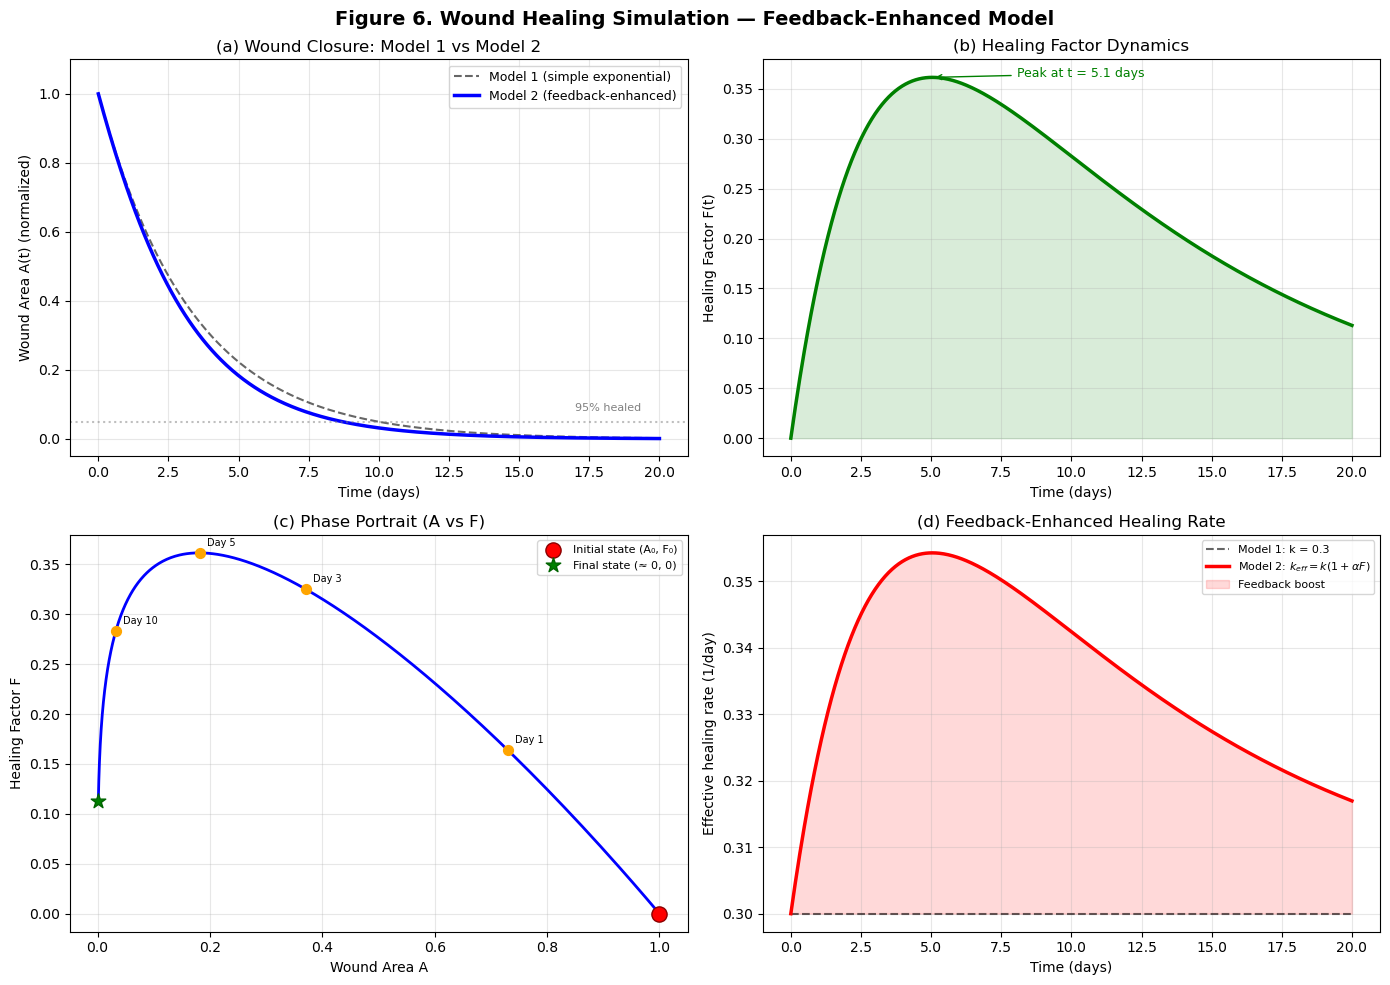

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from dataclasses import dataclass


@dataclass
class WoundParams:
    """Parameters for the feedback-enhanced wound healing model (Model 2)."""
    k: float       # Base healing rate (1/day)
    alpha: float   # Feedback gain (dimensionless)
    beta: float    # Wound-stimulated recruitment of healing factor (1/day)
    gamma: float   # Natural decay rate of healing factor (1/day)


def wound_model(state, t, params: WoundParams):
    """ODE system for Model 2: state = [A, F].

    A = wound area (cm²), F = healing factor (dimensionless).
    """
    A, F = state
    dAdt = -params.k * A * (1 + params.alpha * F)
    dFdt = params.beta * A - params.gamma * F
    return [dAdt, dFdt]


def simulate_wound(params, A0=1.0, F0=0.0, t_max=20, n_points=500):
    """Simulate wound healing and return time, wound area, and healing factor."""
    t = np.linspace(0, t_max, n_points)
    sol = odeint(wound_model, [A0, F0], t, args=(params,))
    return t, sol[:, 0], sol[:, 1]


# --- Standard simulation ---
params = WoundParams(k=0.3, alpha=0.5, beta=0.2, gamma=0.1)
t, A_sol, F_sol = simulate_wound(params)

# Also compute the simple exponential (Model 1) for comparison
A_simple = np.exp(-params.k * t)


# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Wound closure comparison
ax = axes[0, 0]
ax.plot(t, A_simple, 'k--', lw=1.5, alpha=0.6, label='Model 1 (simple exponential)')
ax.plot(t, A_sol, 'b-', lw=2.5, label='Model 2 (feedback-enhanced)')
ax.axhline(y=0.05, color='gray', linestyle=':', alpha=0.5)
ax.text(17, 0.08, '95% healed', fontsize=8, color='gray')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Wound Area A(t) (normalized)')
ax.set_title('(a) Wound Closure: Model 1 vs Model 2')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

# Panel 2: Healing factor dynamics
ax = axes[0, 1]
ax.plot(t, F_sol, 'g-', lw=2.5)
ax.fill_between(t, F_sol, alpha=0.15, color='green')
t_peak = t[np.argmax(F_sol)]
F_peak = np.max(F_sol)
ax.annotate(f'Peak at t = {t_peak:.1f} days',
            xy=(t_peak, F_peak), xytext=(t_peak + 3, F_peak),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='green'),
            color='green')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Healing Factor F(t)')
ax.set_title('(b) Healing Factor Dynamics')
ax.grid(True, alpha=0.3)

# Panel 3: Phase portrait
ax = axes[1, 0]
ax.plot(A_sol, F_sol, 'b-', lw=2)
ax.scatter([A_sol[0]], [F_sol[0]], c='red', s=120, zorder=5,
           label='Initial state (A₀, F₀)', edgecolors='darkred')
ax.scatter([A_sol[-1]], [F_sol[-1]], c='green', s=120, zorder=5, marker='*',
           label='Final state (≈ 0, 0)', edgecolors='darkgreen')

# Add time markers
for day in [1, 3, 5, 10]:
    idx = np.argmin(np.abs(t - day))
    ax.scatter([A_sol[idx]], [F_sol[idx]], c='orange', s=50, zorder=4)
    ax.annotate(f'Day {day}', xy=(A_sol[idx], F_sol[idx]),
                fontsize=7, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Wound Area A')
ax.set_ylabel('Healing Factor F')
ax.set_title('(c) Phase Portrait (A vs F)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 4: Effective healing rate
ax = axes[1, 1]
k_eff = params.k * (1 + params.alpha * F_sol)
ax.plot(t, np.ones_like(t) * params.k, 'k--', lw=1.5, alpha=0.6,
        label=f'Model 1: k = {params.k}')
ax.plot(t, k_eff, 'r-', lw=2.5, label=r'Model 2: $k_{eff} = k(1 + \alpha F)$')
ax.fill_between(t, params.k, k_eff, alpha=0.15, color='red',
                label='Feedback boost')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Effective healing rate (1/day)')
ax.set_title('(d) Feedback-Enhanced Healing Rate')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle('Figure 6. Wound Healing Simulation — Feedback-Enhanced Model',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpreting the simulation results (Figure 6)

The four panels tell the complete story of feedback-enhanced wound healing:

**Panel (a) — Wound Closure**: The feedback-enhanced model (blue) heals *faster* than the simple exponential (dashed black), especially in the first few days. This is because the healing factor $F$ boosts the effective healing rate. Both models predict eventual full closure, but the feedback model reaches 95% healed sooner.

**Panel (b) — Healing Factor Dynamics**: The healing factor $F$ rises rapidly when the wound is large (strong stimulus $\beta A$), peaks after a few days, and then decays as the wound closes and the stimulus weakens. This "recruit → act → retire" pattern mirrors the real biological dynamics of growth factor production during wound repair.

**Panel (c) — Phase Portrait**: The trajectory in $(A, F)$ space shows the system starting at $(1, 0)$ (large wound, no healing factor), looping up as $F$ is recruited, then spiraling down to $(0, 0)$ (healed wound, no residual factor). The characteristic loop shape reflects the transient buildup of repair machinery.

**Panel (d) — Effective Healing Rate**: The key insight: the effective healing rate is *not* constant in Model 2. It peaks early (when $F$ is maximal) and gradually returns to the baseline rate $k$ as $F$ decays. The shaded area represents the "extra" healing provided by the feedback mechanism.

### Check Your Understanding: Simulation Results

**Q10.** Looking at Panel (c), why does the phase portrait show a *loop* rather than a straight line from $(1, 0)$ to $(0, 0)$?

<details>
<summary>Click to reveal answer</summary>

The loop arises because $A$ and $F$ have **different time scales**:

1. Initially, $A$ is large and $F = 0$ — the system starts on the horizontal axis
2. The wound stimulates rapid production of $F$ ($\beta A$ is large), so $F$ rises *while $A$ is still large* — the trajectory moves upward
3. As both $A$ and $F$ are elevated, wound closure accelerates ($k_{\text{eff}}$ is large), so $A$ decreases rapidly
4. Once $A$ becomes small, the stimulus for $F$ vanishes, but $F$ decays slowly (rate $\gamma$) — so $F$ persists briefly even after $A$ is nearly zero

This creates the characteristic loop: $A$ leads the decline (wound closes first), then $F$ follows (healing factor decays afterward). A straight line would require both variables to change at exactly proportional rates, which doesn't happen with different time constants.

</details>

---

**Q11. (DIY — Coding Challenge)** What happens if you set $\alpha = 0$ (no feedback)? Verify that Model 2 reduces to Model 1.

<details>
<summary>Click for hint</summary>

Set `alpha=0` in the `WoundParams` and re-run the simulation. Compare the resulting $A(t)$ with the simple exponential $A_0 e^{-kt}$. What happens to $F(t)$ — does it still rise and fall?

</details>

<details>
<summary>Click to reveal answer</summary>

With $\alpha = 0$:
- The $A$ equation becomes $dA/dt = -kA \cdot (1 + 0) = -kA$ — exactly Model 1
- The $F$ equation is unchanged: $dF/dt = \beta A - \gamma F$
- So $A(t) = A_0 e^{-kt}$ (pure exponential), independent of $F$
- $F$ still rises and falls (the wound still stimulates it), but $F$ has **no effect on healing** — the feedback loop is broken

The $A(t)$ curves for Model 1 and Model 2 (with $\alpha = 0$) will be identical. The healing factor $F$ becomes an "observer" — it tracks the wound state but doesn't influence it.

</details>

### Interactive Wound Healing Simulator

Explore the feedback-enhanced wound healing model (Model 2) by adjusting the parameters with the sliders below. The simulation solves the coupled ODE system in real time:

$$\frac{dA}{dt} = -k \cdot A \cdot (1 + \alpha F), \qquad \frac{dF}{dt} = \beta A - \gamma F$$

#### Adjustable parameters

| Parameter | Symbol | Description | Default | Range | Unit |
|:----------|:------:|:------------|:-------:|:-----:|:-----|
| Base healing rate | $k$ | Intrinsic rate of wound closure (without feedback) | 0.3 | 0.05–1.0 | 1/day |
| Feedback gain | $\alpha$ | How strongly the healing factor $F$ accelerates closure | 0.5 | 0–3.0 | — |
| Recruitment rate | $\beta$ | Rate at which the wound recruits healing factor | 0.2 | 0.01–1.0 | 1/day |
| Decay rate | $\gamma$ | Natural decay rate of the healing factor | 0.1 | 0.01–0.5 | 1/day |
| Initial wound area | $A_0$ | Starting wound size (normalized) | 1.0 | 0.1–3.0 | cm² |
| Simulation time | $T$ | Duration of the simulation | 20 | 5–60 | days |

Use the **preset scenarios** to jump to clinically motivated parameter sets.

In [12]:
from ipywidgets import FloatSlider, VBox, HBox, Button, Output, Layout, HTML as WHTML
import ipywidgets as widgets
from matplotlib.patches import Circle, FancyArrowPatch
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

# ---------------------------------------------------------------------------
#  Sliders
# ---------------------------------------------------------------------------
style = {'description_width': '90px'}
sl_layout = Layout(width='400px')

sl_k     = FloatSlider(value=0.3, min=0.05, max=1.0, step=0.01,
                       description='k (1/day):', style=style, layout=sl_layout,
                       readout_format='.2f')
sl_alpha = FloatSlider(value=0.5, min=0.0, max=3.0, step=0.05,
                       description='α:', style=style, layout=sl_layout,
                       readout_format='.2f')
sl_beta  = FloatSlider(value=0.2, min=0.01, max=1.0, step=0.01,
                       description='β (1/day):', style=style, layout=sl_layout,
                       readout_format='.2f')
sl_gamma = FloatSlider(value=0.1, min=0.01, max=0.5, step=0.01,
                       description='γ (1/day):', style=style, layout=sl_layout,
                       readout_format='.2f')
sl_A0    = FloatSlider(value=1.0, min=0.1, max=3.0, step=0.1,
                       description='A₀ (cm²):', style=style, layout=sl_layout,
                       readout_format='.1f')
sl_tmax  = FloatSlider(value=20, min=5, max=60, step=1,
                       description='T (days):', style=style, layout=sl_layout,
                       readout_format='.0f')

all_sliders = [sl_k, sl_alpha, sl_beta, sl_gamma, sl_A0, sl_tmax]

# ---------------------------------------------------------------------------
#  Presets
# ---------------------------------------------------------------------------
presets = {
    'Normal healing':    dict(k=0.30, alpha=0.50, beta=0.20, gamma=0.10, A0=1.0, T=20),
    'Fast healer':       dict(k=0.50, alpha=1.00, beta=0.40, gamma=0.15, A0=1.0, T=15),
    'Slow / chronic':    dict(k=0.08, alpha=0.10, beta=0.05, gamma=0.03, A0=2.0, T=60),
    'Diabetic wound':    dict(k=0.12, alpha=0.15, beta=0.08, gamma=0.05, A0=1.5, T=45),
    'No feedback (α=0)': dict(k=0.30, alpha=0.00, beta=0.20, gamma=0.10, A0=1.0, T=20),
    'Strong feedback':   dict(k=0.20, alpha=2.50, beta=0.60, gamma=0.08, A0=1.0, T=20),
    'Large wound':       dict(k=0.25, alpha=0.50, beta=0.20, gamma=0.10, A0=3.0, T=40),
}

preset_buttons = []
for name in presets:
    bs = 'info' if name == 'Normal healing' else ''
    b = Button(description=name, layout=Layout(width='auto'), button_style=bs)
    preset_buttons.append(b)

def _set_preset(btn):
    v = presets[btn.description]
    sl_k.value     = v['k']
    sl_alpha.value = v['alpha']
    sl_beta.value  = v['beta']
    sl_gamma.value = v['gamma']
    sl_A0.value    = v['A0']
    sl_tmax.value  = v['T']

for b in preset_buttons:
    b.on_click(_set_preset)

# ---------------------------------------------------------------------------
#  Wound skin color map
# ---------------------------------------------------------------------------
wound_cmap = LinearSegmentedColormap.from_list(
    'wound', ['#f5cba7', '#e74c3c', '#922b21', '#641e16'], N=256)

# ---------------------------------------------------------------------------
#  Simulation + plotting
# ---------------------------------------------------------------------------
out = Output()

def _update(*_):
    k     = sl_k.value
    alpha = sl_alpha.value
    beta  = sl_beta.value
    gamma = sl_gamma.value
    A0    = sl_A0.value
    t_max = sl_tmax.value

    p = WoundParams(k=k, alpha=alpha, beta=beta, gamma=gamma)
    t = np.linspace(0, t_max, 600)
    sol = odeint(wound_model, [A0, 0.0], t, args=(p,))
    A_sol, F_sol = sol[:, 0], sol[:, 1]
    A_simple = A0 * np.exp(-k * t)
    k_eff = k * (1 + alpha * F_sol)

    # Time to 95% healed
    healed_idx = np.argmax(A_sol < 0.05 * A0)
    t_95 = t[healed_idx] if healed_idx > 0 else float('inf')
    healed_idx_s = np.argmax(A_simple < 0.05 * A0)
    t_95_simple = t[healed_idx_s] if healed_idx_s > 0 else float('inf')

    # Snapshot days for wound visualization
    snap_days = np.array([0, 1, 3, 7, 14])
    snap_days = snap_days[snap_days <= t_max]

    with out:
        out.clear_output(wait=True)
        fig = plt.figure(figsize=(14, 9))
        gs = GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

        # ---- Row 1, col 0-1: Wound closure + healing factor ----
        ax1 = fig.add_subplot(gs[0, 0:2])
        ax1.plot(t, A_simple, 'k--', lw=1.5, alpha=0.5, label='Model 1 (exponential)')
        ax1.plot(t, A_sol, 'b-', lw=2.5, label='Model 2 (feedback)')
        ax1.axhline(0.05 * A0, color='gray', ls=':', alpha=0.4)
        ax1.fill_between(t, A_simple, A_sol, where=A_simple > A_sol,
                         alpha=0.10, color='blue', label='Feedback advantage')
        if t_95 < float('inf'):
            ax1.axvline(t_95, color='blue', ls=':', alpha=0.4)
            ax1.text(t_95 + 0.3, A0 * 0.5, f'{t_95:.1f}d', color='blue', fontsize=8)
        if t_95_simple < float('inf'):
            ax1.axvline(t_95_simple, color='gray', ls=':', alpha=0.3)
            ax1.text(t_95_simple + 0.3, A0 * 0.6, f'{t_95_simple:.1f}d', color='gray', fontsize=8)
        ax1.set_xlabel('Time (days)')
        ax1.set_ylabel('Wound area A(t) (cm²)')
        ax1.set_title('(a) Wound Closure', fontsize=11)
        ax1.legend(fontsize=8, loc='upper right')
        ax1.set_ylim(bottom=-0.05 * A0)
        ax1.grid(True, alpha=0.2)

        # ---- Row 1, col 2: Healing factor + effective rate ----
        ax2 = fig.add_subplot(gs[0, 2])
        color_F = '#27ae60'
        color_k = '#c0392b'
        ax2.plot(t, F_sol, '-', color=color_F, lw=2, label='F(t)')
        ax2.fill_between(t, F_sol, alpha=0.12, color=color_F)
        ax2.set_xlabel('Time (days)')
        ax2.set_ylabel('Healing factor F(t)', color=color_F)
        ax2.tick_params(axis='y', labelcolor=color_F)

        ax2b = ax2.twinx()
        ax2b.plot(t, k_eff, '-', color=color_k, lw=2, label='$k_{eff}$')
        ax2b.axhline(k, color='gray', ls='--', lw=1, alpha=0.5)
        ax2b.set_ylabel('$k_{eff}$ (1/day)', color=color_k)
        ax2b.tick_params(axis='y', labelcolor=color_k)

        lines1, lab1 = ax2.get_legend_handles_labels()
        lines2, lab2 = ax2b.get_legend_handles_labels()
        ax2.legend(lines1 + lines2, lab1 + lab2, fontsize=8, loc='upper right')
        ax2.set_title('(b) Healing Factor & Rate', fontsize=11)
        ax2.grid(True, alpha=0.2)

        # ---- Row 2, col 0: Phase portrait ----
        ax3 = fig.add_subplot(gs[1, 0])
        ax3.plot(A_sol, F_sol, 'b-', lw=2)
        ax3.scatter([A_sol[0]], [F_sol[0]], c='red', s=100, zorder=5, edgecolors='darkred')
        ax3.scatter([A_sol[-1]], [F_sol[-1]], c='green', s=100, zorder=5,
                    marker='*', edgecolors='darkgreen')
        for day in [1, 3, 5, 10]:
            if day <= t_max:
                idx = np.argmin(np.abs(t - day))
                ax3.scatter([A_sol[idx]], [F_sol[idx]], c='orange', s=40, zorder=4)
                ax3.annotate(f'd{day}', xy=(A_sol[idx], F_sol[idx]),
                             fontsize=7, xytext=(4, 4), textcoords='offset points')
        ax3.set_xlabel('Wound area A')
        ax3.set_ylabel('Healing factor F')
        ax3.set_title('(c) Phase Portrait', fontsize=11)
        ax3.grid(True, alpha=0.2)

        # ---- Row 2, col 1-2: Wound snapshots (skin lesion visualization) ----
        ax4 = fig.add_subplot(gs[1, 1:3])
        n_snaps = len(snap_days)
        x_positions = np.linspace(0.08, 0.92, n_snaps)

        ax4.set_xlim(0, 1)
        ax4.set_ylim(0, 1)
        ax4.set_aspect('equal')
        ax4.axis('off')
        ax4.set_title('(d) Wound Appearance Over Time', fontsize=11, pad=12)

        skin_color = '#f5cba7'
        max_radius = 0.12
        for i, day in enumerate(snap_days):
            idx = np.argmin(np.abs(t - day))
            area_frac = max(A_sol[idx] / A0, 0)
            radius = max_radius * np.sqrt(area_frac)

            cx, cy = x_positions[i], 0.50

            skin_bg = Circle((cx, cy), max_radius + 0.02, fc=skin_color,
                             ec='#d4a574', lw=1.5, zorder=1)
            ax4.add_patch(skin_bg)

            if radius > 0.003:
                severity = min(area_frac, 1.0)
                wound_color = wound_cmap(severity * 0.8 + 0.2)
                wound = Circle((cx, cy), radius, fc=wound_color,
                               ec='#922b21', lw=1, alpha=0.9, zorder=2)
                ax4.add_patch(wound)

                if radius > 0.01:
                    ring = Circle((cx, cy), radius * 1.15,
                                  fc='none', ec='#e8a0a0', lw=1.5,
                                  ls='--', alpha=0.6, zorder=3)
                    ax4.add_patch(ring)

            pct = (1 - area_frac) * 100
            ax4.text(cx, cy - max_radius - 0.07, f'Day {day}',
                     ha='center', fontsize=9, fontweight='bold')
            ax4.text(cx, cy - max_radius - 0.14, f'{pct:.0f}% healed',
                     ha='center', fontsize=8, color='#555')
            ax4.text(cx, cy - max_radius - 0.20,
                     f'A={A_sol[idx]:.2f} cm²',
                     ha='center', fontsize=7, color='#888')

            if i < n_snaps - 1:
                ax4.annotate('', xy=(x_positions[i+1] - max_radius - 0.03, cy),
                             xytext=(cx + max_radius + 0.03, cy),
                             arrowprops=dict(arrowstyle='->', color='gray',
                                             lw=1.5))

        # Summary text
        summary = (f'k={k:.2f}  α={alpha:.2f}  β={beta:.2f}  γ={gamma:.2f}'
                   f'  |  NFP: {k*(1+alpha*max(F_sol)):.2f} peak rate'
                   f'  |  95% healed: {t_95:.1f}d' if t_95 < float('inf')
                   else f'k={k:.2f}  α={alpha:.2f}  β={beta:.2f}  γ={gamma:.2f}'
                        f'  |  not 95% healed within {t_max:.0f}d')
        fig.suptitle(summary, fontsize=10, color='#333', y=0.98)

        plt.show()

for sl in all_sliders:
    sl.observe(_update, names='value')

btn_row = HBox(preset_buttons, layout=Layout(flex_flow='row wrap', gap='4px'))
slider_col = VBox(all_sliders)
display(WHTML('<b>Preset clinical scenarios:</b>'))
display(btn_row)
display(slider_col)
display(out)

_update()

HTML(value='<b>Preset clinical scenarios:</b>')

Output()

In [13]:
# Static snapshot for PDF / print export (Normal healing defaults)

## 8. Parameter Sensitivity: What Controls Healing Speed?

One of the most powerful uses of computational models is **parameter sensitivity analysis** — understanding which parameters matter most for the system's behavior.

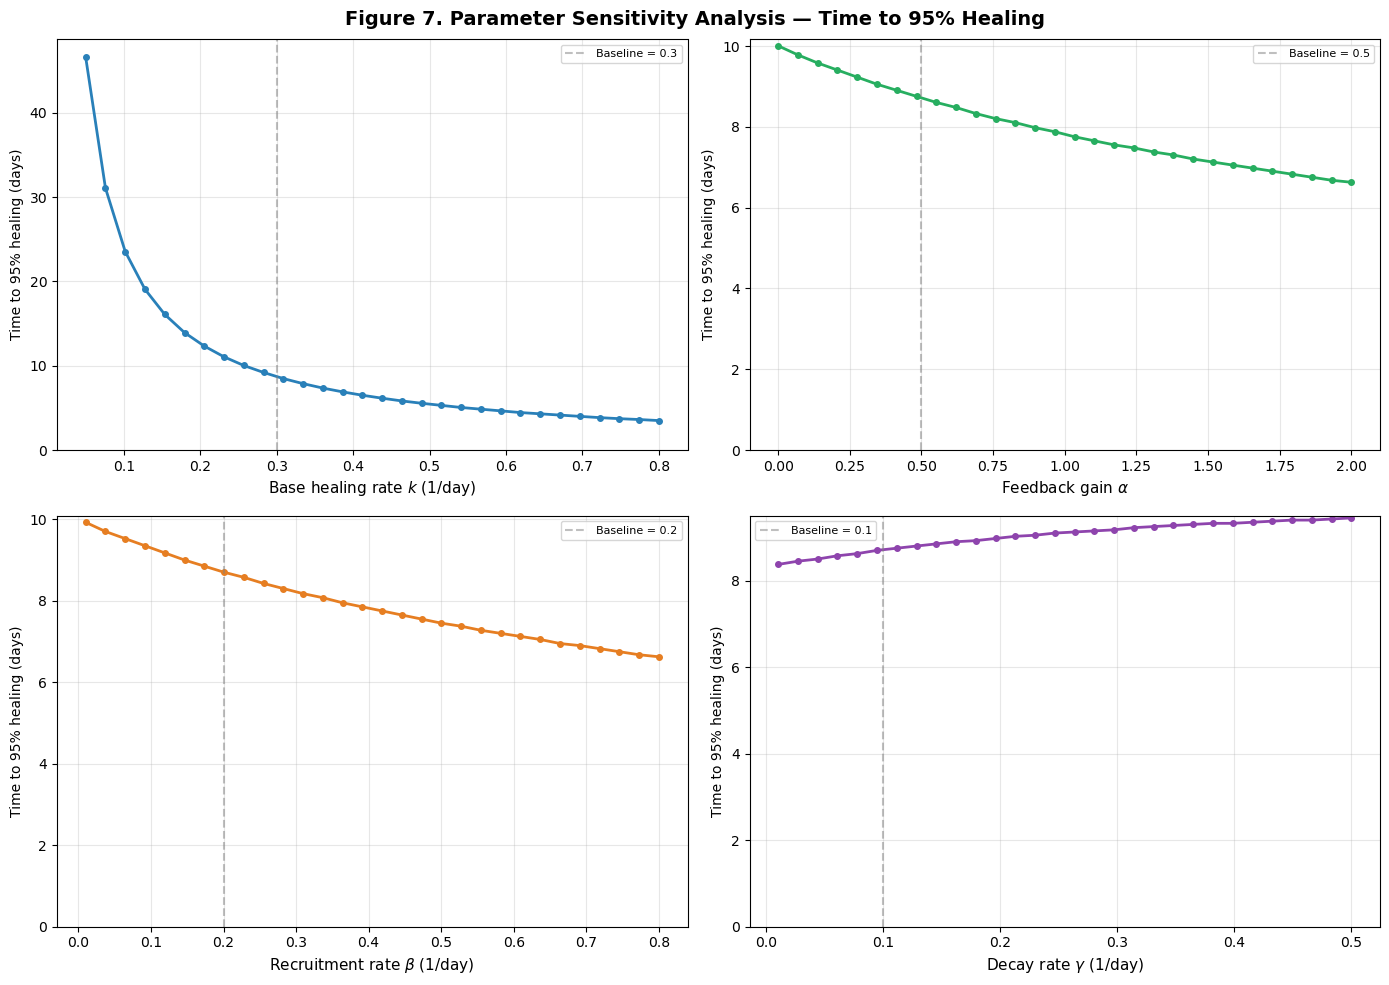

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from dataclasses import dataclass


@dataclass
class WoundParams:
    """Parameters for the feedback-enhanced wound healing model."""
    k: float
    alpha: float
    beta: float
    gamma: float


def wound_model(state, t, params):
    A, F = state
    dAdt = -params.k * A * (1 + params.alpha * F)
    dFdt = params.beta * A - params.gamma * F
    return [dAdt, dFdt]


def time_to_heal(params, threshold=0.05, A0=1.0, t_max=50):
    """Compute the time to reach a given fraction of original wound area."""
    t = np.linspace(0, t_max, 2000)
    sol = odeint(wound_model, [A0, 0.0], t, args=(params,))
    A = sol[:, 0]
    healed_idx = np.where(A < threshold * A0)[0]
    return t[healed_idx[0]] if len(healed_idx) > 0 else t_max


# --- Sensitivity analysis: vary each parameter while keeping others fixed ---
base_params = {'k': 0.3, 'alpha': 0.5, 'beta': 0.2, 'gamma': 0.1}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
param_ranges = {
    'k':     (np.linspace(0.05, 0.8, 30), 'Base healing rate $k$ (1/day)', '#2980b9'),
    'alpha': (np.linspace(0, 2.0, 30),    'Feedback gain $\\alpha$', '#27ae60'),
    'beta':  (np.linspace(0.01, 0.8, 30), 'Recruitment rate $\\beta$ (1/day)', '#e67e22'),
    'gamma': (np.linspace(0.01, 0.5, 30), 'Decay rate $\\gamma$ (1/day)', '#8e44ad'),
}

for ax, (pname, (prange, xlabel, color)) in zip(axes.flat, param_ranges.items()):
    heal_times = []
    for val in prange:
        p = dict(base_params)
        p[pname] = val
        ht = time_to_heal(WoundParams(**p))
        heal_times.append(ht)

    ax.plot(prange, heal_times, 'o-', color=color, lw=2, markersize=4)
    ax.axvline(x=base_params[pname], color='gray', linestyle='--', alpha=0.5,
               label=f'Baseline = {base_params[pname]}')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Time to 95% healing (days)', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, None)

fig.suptitle('Figure 7. Parameter Sensitivity Analysis — Time to 95% Healing',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpreting the sensitivity analysis (Figure 7)

- **$k$ (base healing rate)**: The most impactful parameter. Doubling $k$ roughly halves the healing time. This parameter reflects the intrinsic regenerative capacity of the tissue.
- **$\alpha$ (feedback gain)**: Increasing $\alpha$ speeds healing, but with diminishing returns. Beyond a certain gain, the feedback loop is already maximally effective.
- **$\beta$ (recruitment rate)**: More healing factor production → faster healing, but the effect saturates because $F$ is already adequately recruited at moderate $\beta$.
- **$\gamma$ (decay rate)**: Higher decay means $F$ doesn't persist long enough to help. Very low $\gamma$ means $F$ persists long after the wound closes (wasteful but not harmful in this model). The optimum is intermediate.

**Clinical relevance**: These sensitivities map to real therapeutic targets:
- Increasing $k$: improving blood supply (hyperbaric oxygen, growth factors)
- Increasing $\alpha$: enhancing growth factor receptor sensitivity
- Increasing $\beta$: recruiting more fibroblasts (stem cell therapy, PDGF application)
- Decreasing $\gamma$: sustained-release drug delivery to maintain growth factor levels

## 9. Extended Model: Acute vs. Chronic Wound Dynamics

Let us now implement the extended Model 3 (with inflammation) and demonstrate how the same model can produce both acute healing and chronic wound behavior depending on the parameters.

/tmp/ipykernel_42543/154118703.py:47: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol_chronic = odeint(extended_wound_model, y0, t, args=(params_chronic,))


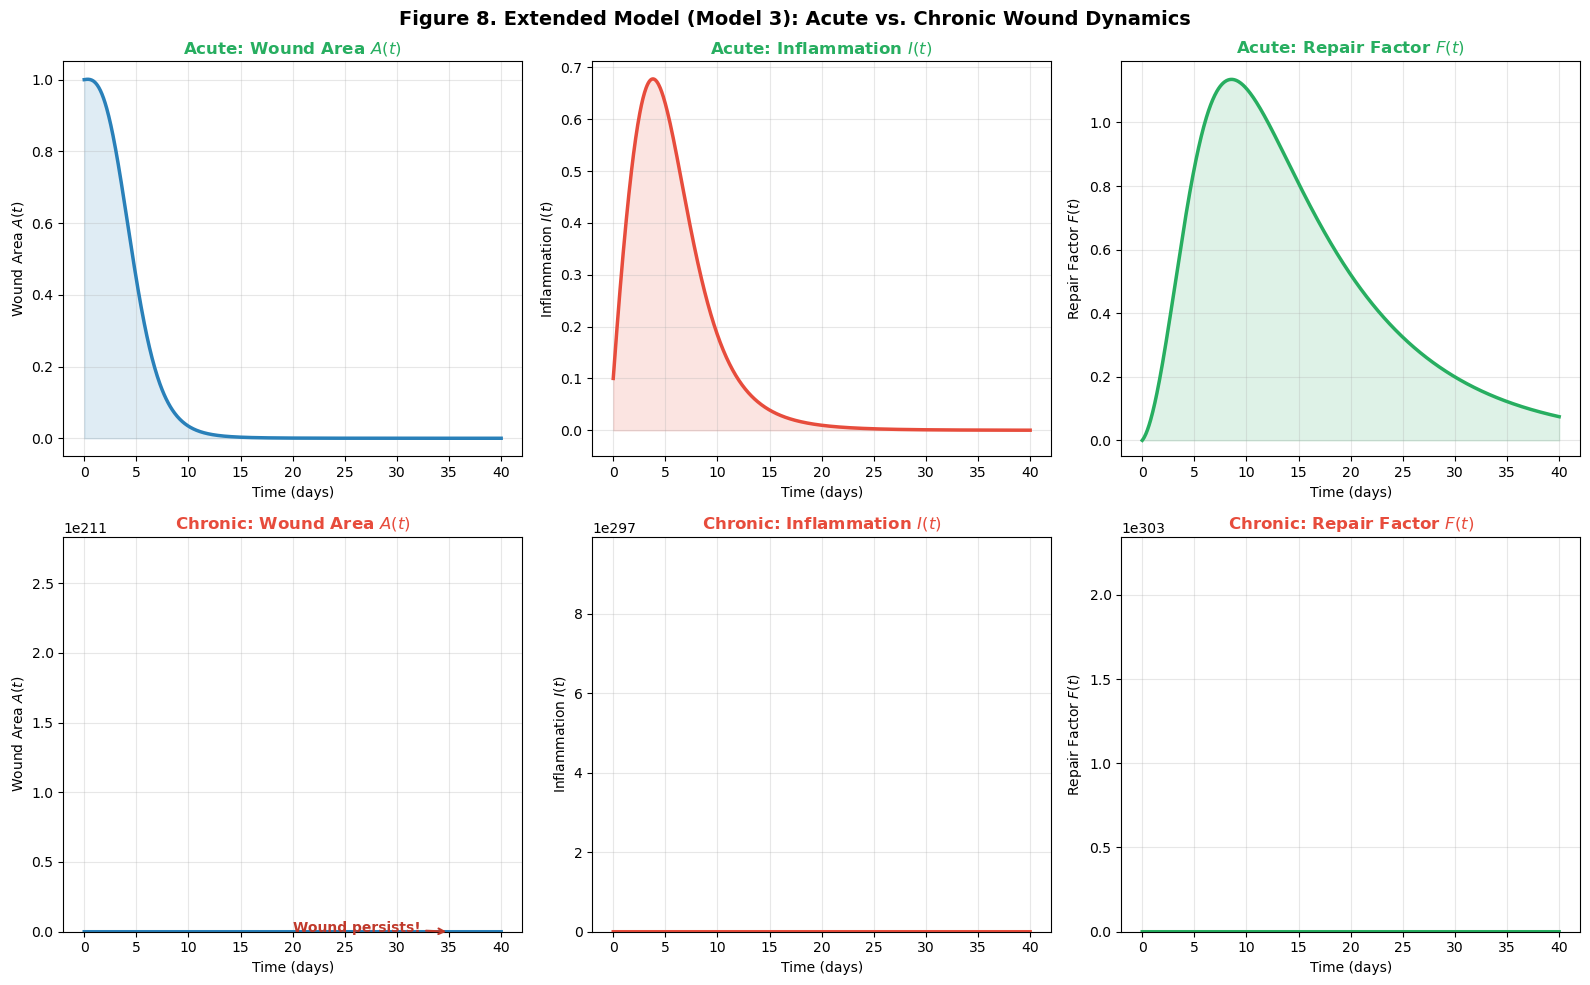

Acute wound — final area:  0.0001 (healed)
Chronic wound — final area: 0.0000 (persists)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from dataclasses import dataclass


@dataclass
class ExtendedWoundParams:
    """Parameters for the extended wound healing model with inflammation (Model 3)."""
    k1: float      # Repair rate (fibroblast-mediated)
    k2: float      # Inflammatory damage rate
    beta_I: float  # Wound-stimulated inflammatory recruitment
    gamma_I: float # Inflammatory cell decay
    delta: float   # Anti-inflammatory effect of repair factors
    beta_F: float  # Inflammation-stimulated fibroblast recruitment
    gamma_F: float # Fibroblast decay


def extended_wound_model(state, t, p):
    """ODE system for Model 3: state = [A, I, F]."""
    A, I, F = state
    A = max(A, 0)  # prevent negative wound area
    I = max(I, 0)
    F = max(F, 0)
    dAdt = -p.k1 * A * F + p.k2 * A * I
    dIdt = p.beta_I * A - p.gamma_I * I - p.delta * I * F
    dFdt = p.beta_F * I - p.gamma_F * F
    return [dAdt, dIdt, dFdt]


# --- Scenario 1: Normal (acute) healing ---
params_acute = ExtendedWoundParams(
    k1=0.5, k2=0.05, beta_I=0.3, gamma_I=0.2,
    delta=0.15, beta_F=0.4, gamma_F=0.1
)

# --- Scenario 2: Chronic wound (impaired healing) ---
params_chronic = ExtendedWoundParams(
    k1=0.15, k2=0.12, beta_I=0.5, gamma_I=0.08,
    delta=0.03, beta_F=0.1, gamma_F=0.15
)

t = np.linspace(0, 40, 800)
y0 = [1.0, 0.1, 0.0]  # initial: wound, small inflammation, no repair yet

sol_acute = odeint(extended_wound_model, y0, t, args=(params_acute,))
sol_chronic = odeint(extended_wound_model, y0, t, args=(params_chronic,))

# --- Visualization ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

labels = ['Wound Area $A(t)$', 'Inflammation $I(t)$', 'Repair Factor $F(t)$']
colors = ['#2980b9', '#e74c3c', '#27ae60']

for j in range(3):
    # Acute
    ax = axes[0, j]
    ax.plot(t, sol_acute[:, j], color=colors[j], lw=2.5)
    ax.fill_between(t, sol_acute[:, j], alpha=0.15, color=colors[j])
    ax.set_xlabel('Time (days)')
    ax.set_ylabel(labels[j])
    ax.set_title(f'Acute: {labels[j]}', fontweight='bold', color='#27ae60')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=-0.05)

    # Chronic
    ax = axes[1, j]
    ax.plot(t, sol_chronic[:, j], color=colors[j], lw=2.5)
    ax.fill_between(t, sol_chronic[:, j], alpha=0.15, color=colors[j])
    ax.set_xlabel('Time (days)')
    ax.set_ylabel(labels[j])
    ax.set_title(f'Chronic: {labels[j]}', fontweight='bold', color='#e74c3c')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=-0.05)

# Annotate chronic wound persistence
axes[1, 0].annotate('Wound persists!', xy=(35, sol_chronic[-1, 0]),
                     xytext=(20, sol_chronic[-1, 0] + 0.3),
                     fontsize=10, color='#c0392b', fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))

fig.suptitle('Figure 8. Extended Model (Model 3): Acute vs. Chronic Wound Dynamics',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Acute wound — final area:  {sol_acute[-1, 0]:.4f} (healed)")
print(f"Chronic wound — final area: {sol_chronic[-1, 0]:.4f} (persists)")

### Interpreting Model 3 (Figure 8)

**Acute wound (top row)**:
- Wound area decreases steadily toward zero
- Inflammation peaks early and then resolves (the anti-inflammatory feedback $\delta \cdot I \cdot F$ works effectively)
- Repair factor $F$ rises, peaks, and then decays as the wound closes
- This is the normal, healthy healing trajectory

**Chronic wound (bottom row)**:
- Wound area decreases initially but then **plateaus** at a nonzero value — the wound *never fully heals*
- Inflammation remains elevated (persistent, unresolved inflammation)
- Repair factor is weak and cannot overcome the inflammatory damage
- The system has found a **pathological steady state** — a stable equilibrium with $A^* > 0$

**The cybernetic failure**: In the chronic scenario, the negative feedback loop (repair → inflammation resolution) is too weak ($\delta$ is small, $\beta_F$ is small), while the positive-feedback-like inflammatory damage loop ($k_2 \cdot A \cdot I$ sustains damage → sustained $A$ → sustained $I$) dominates. The wound is trapped.

/tmp/ipykernel_42543/3263013778.py:30: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol_pre = odeint(extended_wound_model, y0, t_pre, args=(params_chronic,))


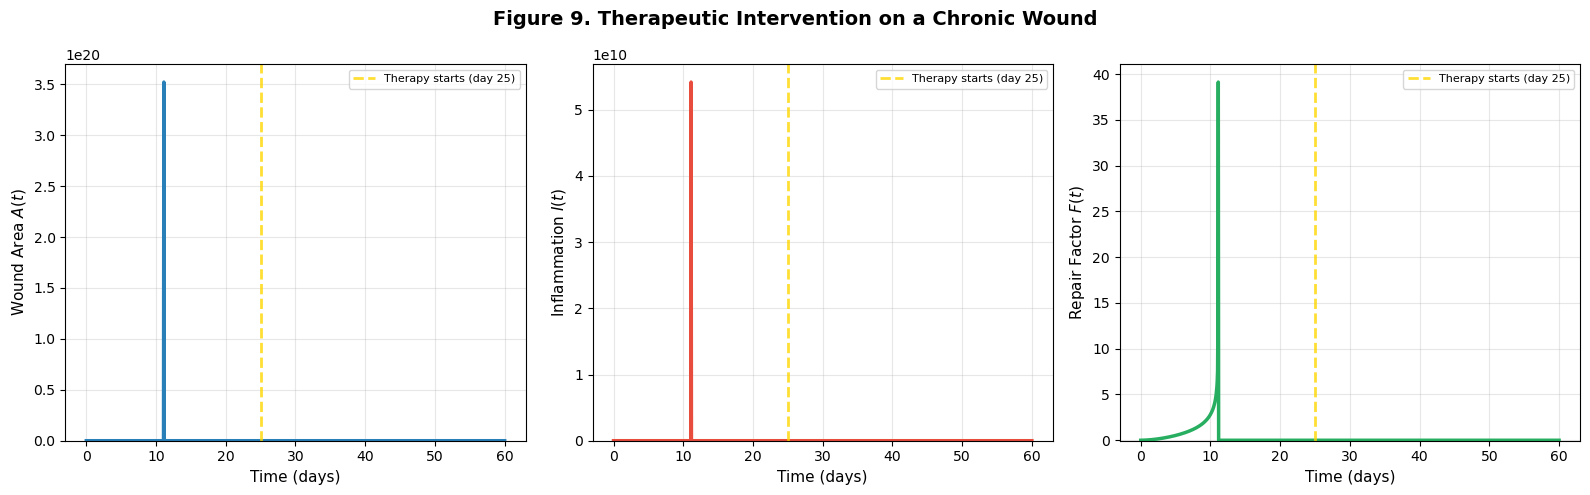

Wound area at day 25 (before therapy): 0.000
Wound area at day 60 (after therapy):  0.0000


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from dataclasses import dataclass


@dataclass
class ExtendedWoundParams:
    k1: float; k2: float; beta_I: float; gamma_I: float
    delta: float; beta_F: float; gamma_F: float


def extended_wound_model(state, t, p):
    A, I, F = [max(s, 0) for s in state]
    dAdt = -p.k1 * A * F + p.k2 * A * I
    dIdt = p.beta_I * A - p.gamma_I * I - p.delta * I * F
    dFdt = p.beta_F * I - p.gamma_F * F
    return [dAdt, dIdt, dFdt]


# --- Simulating a therapeutic intervention on a chronic wound ---
params_chronic = ExtendedWoundParams(
    k1=0.15, k2=0.12, beta_I=0.5, gamma_I=0.08,
    delta=0.03, beta_F=0.1, gamma_F=0.15
)

# Chronic wound simulation up to intervention time
t_pre = np.linspace(0, 25, 500)
y0 = [1.0, 0.1, 0.0]
sol_pre = odeint(extended_wound_model, y0, t_pre, args=(params_chronic,))

# At day 25, apply therapy: boost repair and anti-inflammatory effects
params_treated = ExtendedWoundParams(
    k1=0.45, k2=0.12, beta_I=0.5, gamma_I=0.08,
    delta=0.20, beta_F=0.35, gamma_F=0.15
)

t_post = np.linspace(25, 60, 700)
y0_post = sol_pre[-1]  # continue from chronic state
sol_post = odeint(extended_wound_model, y0_post, t_post, args=(params_treated,))

# Combine
t_full = np.concatenate([t_pre, t_post])
sol_full = np.vstack([sol_pre, sol_post])

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = ['Wound Area $A(t)$', 'Inflammation $I(t)$', 'Repair Factor $F(t)$']
colors = ['#2980b9', '#e74c3c', '#27ae60']

for j, ax in enumerate(axes):
    ax.plot(t_full, sol_full[:, j], color=colors[j], lw=2.5)
    ax.axvline(x=25, color='gold', linestyle='--', lw=2, alpha=0.8,
               label='Therapy starts (day 25)')
    ax.fill_between(t_full[t_full >= 25], 0,
                    sol_full[t_full >= 25, j].max() * 1.1,
                    alpha=0.05, color='gold')
    ax.set_xlabel('Time (days)', fontsize=11)
    ax.set_ylabel(labels[j], fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=-0.05)

fig.suptitle('Figure 9. Therapeutic Intervention on a Chronic Wound',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Wound area at day 25 (before therapy): {sol_pre[-1, 0]:.3f}")
print(f"Wound area at day 60 (after therapy):  {sol_full[-1, 0]:.4f}")

### Interpreting the therapeutic intervention (Figure 9)

This simulation demonstrates a key clinical concept: a chronic wound that has been stalled for weeks can be **rescued** by modifying the right parameters.

**Before therapy (days 0–25)**: The wound stalls at a nonzero area. Inflammation persists. Repair is inadequate.

**At day 25, therapy starts**: We model a combined intervention that:
- Increases $k_1$ (e.g., growth factor application or hyperbaric oxygen → enhanced fibroblast function)
- Increases $\delta$ (e.g., anti-inflammatory drug → helps resolve chronic inflammation)
- Increases $\beta_F$ (e.g., stem cell therapy → more fibroblast recruitment)

**After therapy (days 25–60)**: The wound resumes healing, inflammation resolves, and the wound closes.

In cybernetic terms, the therapy **restores the broken feedback loop** — the system transitions from the pathological steady state back to the healthy healing trajectory. This is the fundamental principle behind modern evidence-based wound care.

### Check Your Understanding: Extended Model & Therapy

**Q12.** In the chronic wound simulation, the wound area plateaus rather than continuing to grow. Why doesn't the wound get *worse* over time if the feedback loop is broken?

<details>
<summary>Click to reveal answer</summary>

Even in the chronic scenario, the wound doesn't grow without bound because:

1. The inflammatory damage term is $k_2 \cdot A \cdot I$ — it depends on the *current wound area*. As the wound reaches a certain size, the repair term $k_1 \cdot A \cdot F$ and the damage term $k_2 \cdot A \cdot I$ reach a **balance**
2. At this balance point: $k_1 F^* = k_2 I^*$ — the rate of repair exactly equals the rate of damage
3. The wound is in a **stable steady state** — not getting better, not getting worse

This is clinically accurate: chronic wounds typically maintain a relatively stable size for extended periods. They don't "run away" (unlike, say, a tumor) because the damage-repair balance constrains them. But they also don't heal — they are stuck in a local equilibrium.

</details>

---

**Q13.** In Figure 9, why is it important that the therapy increases *both* $k_1$ (repair) and $\delta$ (anti-inflammatory), rather than just one?

<details>
<summary>Click to reveal answer</summary>

Chronic wounds involve *two coupled problems*:
1. **Insufficient repair** (low $k_1$) — fibroblasts can't keep up with damage
2. **Unresolved inflammation** (low $\delta$) — inflammatory cells persist and cause ongoing tissue damage

If you only increase $k_1$ (more repair) without resolving inflammation:
- The persistent inflammation ($I$ stays high) continues damaging tissue ($k_2 \cdot A \cdot I$)
- You're fighting a losing battle: repairing while simultaneously destroying

If you only increase $\delta$ (reduce inflammation) without boosting repair:
- Inflammation may resolve, but the intrinsic repair capacity is still weak
- Healing will be slow and incomplete

**Combined therapy** breaks the vicious cycle from both sides: resolve inflammation *and* boost repair. This is why evidence-based chronic wound management uses multimodal approaches (debridement + anti-inflammatory + growth factors + moisture management).

In control theory terms: you need to fix both the **sensor/controller** (inflammation resolution) and the **actuator** (repair capacity) to restore proper feedback control.

</details>

## 10. DIY Exercises: Explore Further

### Exercise 1: Compare Healing Rates Across Wound Sizes

Does a larger wound take proportionally longer to heal, or is the relationship nonlinear? Simulate Model 2 for initial wound areas $A_0 = 0.5, 1.0, 2.0, 5.0$ cm² and plot the time to 95% closure vs. $A_0$.

<details>
<summary>Click for starter code</summary>

```python
params = WoundParams(k=0.3, alpha=0.5, beta=0.2, gamma=0.1)
A0_values = [0.5, 1.0, 2.0, 5.0]

plt.figure(figsize=(10, 6))
for A0 in A0_values:
    t, A, F = simulate_wound(params, A0=A0, t_max=30)
    plt.plot(t, A / A0, lw=2, label=f'$A_0$ = {A0} cm²')

plt.xlabel('Time (days)')
plt.ylabel('Fraction remaining (A/A₀)')
plt.title('Wound Closure for Different Initial Sizes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
```

</details>

<details>
<summary>Click to reveal what you should see</summary>

When plotted as **fraction remaining** ($A/A_0$), all curves overlap nearly perfectly for Model 1 (simple exponential), because $A/A_0 = e^{-kt}$ is independent of $A_0$.

For Model 2 (feedback-enhanced), larger wounds generate **more healing factor** (since $dF/dt = \beta A$), so they close *proportionally faster*. The normalized curves for large $A_0$ will drop more steeply in the early phase. This is a prediction of the model that could be tested experimentally!

</details>

---

### Exercise 2: Bioelectronic Wound Controller

Imagine a smart bandage that continuously monitors wound area $A(t)$ and delivers an electrical stimulus proportional to $A$. Model this as an **external input** $u(t) = K_p \cdot A(t)$ that adds to the healing factor production:

$$\frac{dF}{dt} = \beta A - \gamma F + K_p \cdot A$$

Simulate the effect of this bioelectronic controller with different gains $K_p = 0, 0.1, 0.3, 0.5$.

<details>
<summary>Click for starter code</summary>

```python
def wound_model_controlled(state, t, params, Kp):
    A, F = state
    dAdt = -params.k * A * (1 + params.alpha * F)
    dFdt = params.beta * A - params.gamma * F + Kp * A  # external controller
    return [dAdt, dFdt]

params = WoundParams(k=0.3, alpha=0.5, beta=0.2, gamma=0.1)
t = np.linspace(0, 20, 500)

plt.figure(figsize=(10, 6))
for Kp in [0, 0.1, 0.3, 0.5]:
    sol = odeint(wound_model_controlled, [1.0, 0.0], t, args=(params, Kp))
    plt.plot(t, sol[:, 0], lw=2, label=f'$K_p$ = {Kp}')

plt.xlabel('Time (days)')
plt.ylabel('Wound Area A(t)')
plt.title('Effect of Bioelectronic Controller Gain')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
```

</details>

<details>
<summary>Click to reveal what you should see</summary>

Higher $K_p$ → faster healing. The bioelectronic controller effectively increases the total healing factor production rate from $\beta A$ to $(\beta + K_p) A$. This is equivalent to increasing $\beta$ — the smart bandage supplements the body's natural repair signaling.

For the chronic wound model (Model 3), a bioelectronic controller could be the intervention that tips the balance from pathological steady state to healing. This is the basis of the Selberg et al. (2021) paper.

</details>

---

### Exercise 3: The Bacterial IFFL Controller

An **incoherent feed-forward loop (IFFL)** is a genetic circuit where input $X$ activates output $Z$ directly, but also activates repressor $Y$ that inhibits $Z$. This creates a **pulse** response: $Z$ rises quickly then falls, even if $X$ persists.

Pedersen et al. (2019) proposed using bacteria with an IFFL to deliver anti-inflammatory molecules at the wound site. The bacteria sense inflammation ($I$) and release anti-inflammatory factor $C$:

$$\frac{dC}{dt} = \frac{\mu \cdot I}{K_m + I} \cdot \frac{1}{1 + Y/K_Y} - \gamma_C \cdot C$$

$$\frac{dY}{dt} = \nu \cdot I - \gamma_Y \cdot Y$$

where $C$ reduces inflammation by adding $-\eta \cdot C \cdot I$ to the $dI/dt$ equation.

<details>
<summary>Click for hint on implementing this</summary>

Add $C$ and $Y$ as two new state variables to Model 3. The key parameters are:
- $\mu$: production rate of anti-inflammatory molecule
- $K_m$: Michaelis-Menten constant (sensitivity to inflammation)
- $K_Y$: inhibition constant for the repressor
- $\nu$: repressor production rate
- $\eta$: effectiveness of the bacterial controller

The IFFL ensures that the bacteria deliver a strong but *transient* anti-inflammatory pulse — avoiding the problem of excessive immunosuppression.

</details>

<details>
<summary>Click to reveal expected behavior</summary>

With the IFFL controller:
1. When inflammation is high, the bacteria produce a burst of anti-inflammatory molecule $C$
2. But the IFFL repressor $Y$ builds up, shutting off $C$ production even if $I$ remains elevated
3. This creates a **self-limiting** pulse of therapy — the bacteria don't over-suppress the immune system
4. If inflammation recurs, the system can fire again (once $Y$ decays)

This is a beautiful example of **synthetic biology meets cybernetics**: engineering biological feedback controllers using the mathematical principles of control theory.

</details>

---

### Exercise 4: Modify the Spatial PDE Model (Advanced)

Section 11 below implements a complete spatial wound healing model using coupled reaction-diffusion PDEs. After studying it, try these modifications:

1. **Chemotaxis**: Add a chemotactic term $-\chi \frac{\partial}{\partial x}\left(n \frac{\partial c}{\partial x}\right)$ to the cell equation. How does directed migration toward growth factor gradients change the healing speed?

2. **Chronic spatial wound**: Reduce the proliferation rate $s$ and diffusion $D_n$ to simulate a chronic wound. Does the traveling wave stall?

3. **Asymmetric wound**: Use asymmetric initial conditions (one edge heals faster than the other). What determines the overall closure time?

<details>
<summary>Click for hint on chemotaxis</summary>

The chemotactic flux is discretized as:
```python
# Chemotactic term: -chi * d/dx (n * dc/dx)
dc_dx = np.gradient(c, dx)
chemotaxis = -chi * np.gradient(n * dc_dx, dx)
```
Add `chemotaxis` to the right-hand side of the $n$ equation. Start with $\chi = 0.01$ and increase gradually — too much chemotaxis can cause numerical instability (cell density blow-up).

</details>

In [17]:
# ── DIY: Implement the exercises above ─────────────────────
# Use this cell to experiment. The WoundParams, wound_model,
# simulate_wound, ExtendedWoundParams, and extended_wound_model
# functions from earlier cells are available.
#
# Starter code is provided in the exercise descriptions above.
# Uncomment and modify to explore!

# Example: Exercise 1 — compare wound sizes
# params = WoundParams(k=0.3, alpha=0.5, beta=0.2, gamma=0.1)
# for A0 in [0.5, 1.0, 2.0, 5.0]:
#     t, A, F = simulate_wound(params, A0=A0, t_max=30)
#     plt.plot(t, A / A0, lw=2, label=f'A₀ = {A0}')
# plt.legend(); plt.show()

## 11. Spatial Wound Healing: A PDE-Based Approach

### From ODE to PDE: Why space matters

All the models above (Models 1–3) treat the wound as a **well-mixed compartment** — a single number $A(t)$ describes the wound. In reality, wound healing is fundamentally **spatial**: cells migrate from the wound edges inward, growth factor gradients guide cell movement, and the wound shape and size directly affect closure dynamics.

In this section, we implement a **coupled reaction-diffusion PDE system** — a state-of-the-art framework that has been the backbone of spatial wound healing modeling since the seminal work of Sherratt & Murray (1990). We extend their classic approach with growth factor and extracellular matrix (ECM) dynamics, drawing on the comprehensive models of Menon et al. (2012) and the reviews by Flegg et al. (2020) and Menon & Flegg (2021).

### Literature basis

| Reference | Contribution |
|-----------|-------------|
| **Sherratt & Murray (1990)** | Fisher-KPP equation for epidermal wound healing — cells migrate (diffusion) and proliferate (logistic growth), producing traveling wave solutions |
| **Menon et al. (2012)** | Coupled 8-component PDE system with fibroblasts, keratinocytes, growth factors (TGF-β, PDGF, IL-1, KGF), collagen, and fibrin |
| **Flegg et al. (2020)** | Review of PDE models for wound healing and angiogenesis; emphasis on oxygen, chemotaxis, and mechanical effects |
| **Menon & Flegg (2021)** | Comprehensive review: how mathematical models advance wound healing research |
| **Zanca & Flegg (2022)** | Push or pull? Cell proliferation vs. migration; contact inhibition and the proliferative hub |

### The coupled reaction-diffusion model

We model a **1D cross-section** through a wound (position $x$, time $t$) with three coupled state variables:

#### State variable 1: Cell density $n(x, t)$

$$\frac{\partial n}{\partial t} = \underbrace{D_n \frac{\partial^2 n}{\partial x^2}}_{\text{random migration}} + \underbrace{s \cdot n \left(1 - \frac{n}{n_{\max}}\right) \cdot (1 + \sigma c)}_{\text{growth-factor-enhanced logistic proliferation}}$$

- $D_n$: cell diffusion coefficient (random motility, ~$10^{-10}$ cm²/s for keratinocytes)
- $s$: intrinsic proliferation rate
- $n_{\max}$: carrying capacity (contact inhibition — cells stop dividing when crowded)
- $\sigma$: growth factor enhancement of proliferation

This is a **generalized Fisher-KPP equation**. The classic Fisher-KPP equation ($\sigma = 0$) has traveling wave solutions with minimum speed $v_{\min} = 2\sqrt{D_n \cdot s}$. The growth factor coupling accelerates the wave.

#### State variable 2: Growth factor concentration $c(x, t)$

$$\frac{\partial c}{\partial t} = \underbrace{D_c \frac{\partial^2 c}{\partial x^2}}_{\text{diffusion}} + \underbrace{\alpha \cdot n}_{\text{secretion by cells}} - \underbrace{\delta_c \cdot c}_{\text{natural decay}}$$

- $D_c \gg D_n$: growth factors diffuse much faster than cells migrate
- $\alpha$: secretion rate by cells (autocrine/paracrine signaling)
- $\delta_c$: decay rate of growth factor

The growth factor diffuses *ahead* of the cell front, creating a chemical gradient that (in more advanced models) can guide cell migration via chemotaxis.

#### State variable 3: Extracellular matrix (ECM) density $\rho(x, t)$

$$\frac{\partial \rho}{\partial t} = \underbrace{\beta \cdot n \left(1 - \frac{\rho}{\rho_{\max}}\right)}_{\text{synthesis by cells}} - \underbrace{\delta_\rho \cdot \rho}_{\text{MMP-mediated degradation}}$$

- $\beta$: ECM production rate by fibroblasts
- $\rho_{\max}$: maximum ECM density (saturation)
- $\delta_\rho$: degradation by matrix metalloproteinases (MMPs)

ECM deposition follows behind the cell front — cells must be present to synthesize collagen.

### Initial and boundary conditions

We model a **1D wound** of width $2L_w$ centered at $x = 0$:

| Region | $n(x, 0)$ | $c(x, 0)$ | $\rho(x, 0)$ |
|--------|-----------|-----------|-------------|
| Wound ($|x| < L_w$) | 0 (no cells) | 0 | 0 (destroyed ECM) |
| Healthy tissue ($|x| \geq L_w$) | $n_{\max}$ | $c_{\text{eq}} = \alpha n_{\max} / \delta_c$ | $\rho_{\max}$ |

**Boundary conditions**: Neumann (no-flux) at both ends: $\partial n / \partial x = \partial c / \partial x = \partial \rho / \partial x = 0$.

### Numerical method

We use the **method of lines**: discretize space into $N$ grid points with spacing $\Delta x$, approximate the Laplacian with central finite differences, and solve the resulting system of $3N$ coupled ODEs using `scipy.integrate.solve_ivp` with an adaptive time-stepping method (RK45).

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from dataclasses import dataclass


@dataclass
class SpatialWoundParams:
    """Parameters for the coupled reaction-diffusion wound healing PDE.

    Based on Sherratt & Murray (1990), extended with growth factor
    and ECM dynamics following Menon et al. (2012).
    """
    # Cell migration and proliferation
    D_n: float = 1e-3    # Cell diffusion coefficient (cm²/day)
    s: float = 0.8       # Proliferation rate (1/day)
    n_max: float = 1.0   # Max cell density (carrying capacity, normalized)
    sigma: float = 0.5   # Growth factor enhancement of proliferation

    # Growth factor
    D_c: float = 5e-2    # GF diffusion coefficient (cm²/day, >> D_n)
    alpha: float = 0.5   # GF secretion rate by cells
    delta_c: float = 0.3 # GF decay rate (1/day)

    # Extracellular matrix
    beta: float = 0.3    # ECM production rate
    rho_max: float = 1.0 # Max ECM density (normalized)
    delta_rho: float = 0.02  # ECM degradation rate (1/day)


def spatial_wound_rhs(t, y, params, N, dx):
    """Right-hand side for the method-of-lines discretization.

    y = [n_0, ..., n_{N-1}, c_0, ..., c_{N-1}, rho_0, ..., rho_{N-1}]
    """
    n = y[:N]
    c = y[N:2*N]
    rho = y[2*N:3*N]

    n = np.clip(n, 0, None)
    c = np.clip(c, 0, None)
    rho = np.clip(rho, 0, None)

    def laplacian(u):
        lap = np.zeros_like(u)
        lap[1:-1] = (u[:-2] - 2*u[1:-1] + u[2:]) / dx**2
        lap[0] = (u[1] - u[0]) / dx**2
        lap[-1] = (u[-2] - u[-1]) / dx**2
        return lap

    p = params

    # Cell density: generalized Fisher-KPP
    dn = (p.D_n * laplacian(n)
          + p.s * n * (1 - n / p.n_max) * (1 + p.sigma * c))

    # Growth factor: diffusion + secretion - decay
    dc = p.D_c * laplacian(c) + p.alpha * n - p.delta_c * c

    # ECM: synthesis by cells - degradation
    drho = p.beta * n * (1 - rho / p.rho_max) - p.delta_rho * rho

    return np.concatenate([dn, dc, drho])


def simulate_spatial_wound(params=None, L=1.0, L_w=0.2, N=201,
                           t_max=10, n_save=100):
    """Simulate 1D spatial wound healing.

    Parameters
    ----------
    params : SpatialWoundParams
    L : float  — half-domain size (cm), domain is [-L, L]
    L_w : float — half-wound width (cm), wound is [-L_w, L_w]
    N : int  — number of spatial grid points
    t_max : float — simulation duration (days)
    n_save : int — number of time points to save
    """
    if params is None:
        params = SpatialWoundParams()

    x = np.linspace(-L, L, N)
    dx = x[1] - x[0]

    # Initial conditions with smooth wound edges
    edge_width = 3 * dx
    wound_profile = 0.5 * (
        np.tanh((x + L_w) / edge_width) - np.tanh((x - L_w) / edge_width)
    )
    n0 = params.n_max * (1 - wound_profile)
    n0 = np.clip(n0, 0, params.n_max)

    c_eq = params.alpha * params.n_max / params.delta_c
    c0 = c_eq * np.where(np.abs(x) >= L_w, 1.0, 0.0)
    rho0 = params.rho_max * np.where(np.abs(x) >= L_w, 1.0, 0.0)

    y0 = np.concatenate([n0, c0, rho0])
    t_eval = np.linspace(0, t_max, n_save)

    sol = solve_ivp(
        spatial_wound_rhs, [0, t_max], y0,
        args=(params, N, dx),
        t_eval=t_eval, method='RK45',
        rtol=1e-6, atol=1e-8, max_step=0.01
    )

    return {
        'x': x, 't': sol.t,
        'n': sol.y[:N, :],
        'c': sol.y[N:2*N, :],
        'rho': sol.y[2*N:3*N, :],
        'params': params,
        'L_w': L_w,
    }


# --- Run simulation ---
print("Solving coupled reaction-diffusion PDE system...")
result = simulate_spatial_wound()
print(f"Done. Grid: {len(result['x'])} points, "
      f"Time: {len(result['t'])} frames.")
print(f"Fisher-KPP wave speed (theoretical): "
      f"v = 2*sqrt(D_n*s) = "
      f"{2*np.sqrt(result['params'].D_n * result['params'].s):.4f} cm/day")

Solving coupled reaction-diffusion PDE system...
Done. Grid: 201 points, Time: 100 frames.
Fisher-KPP wave speed (theoretical): v = 2*sqrt(D_n*s) = 0.0566 cm/day


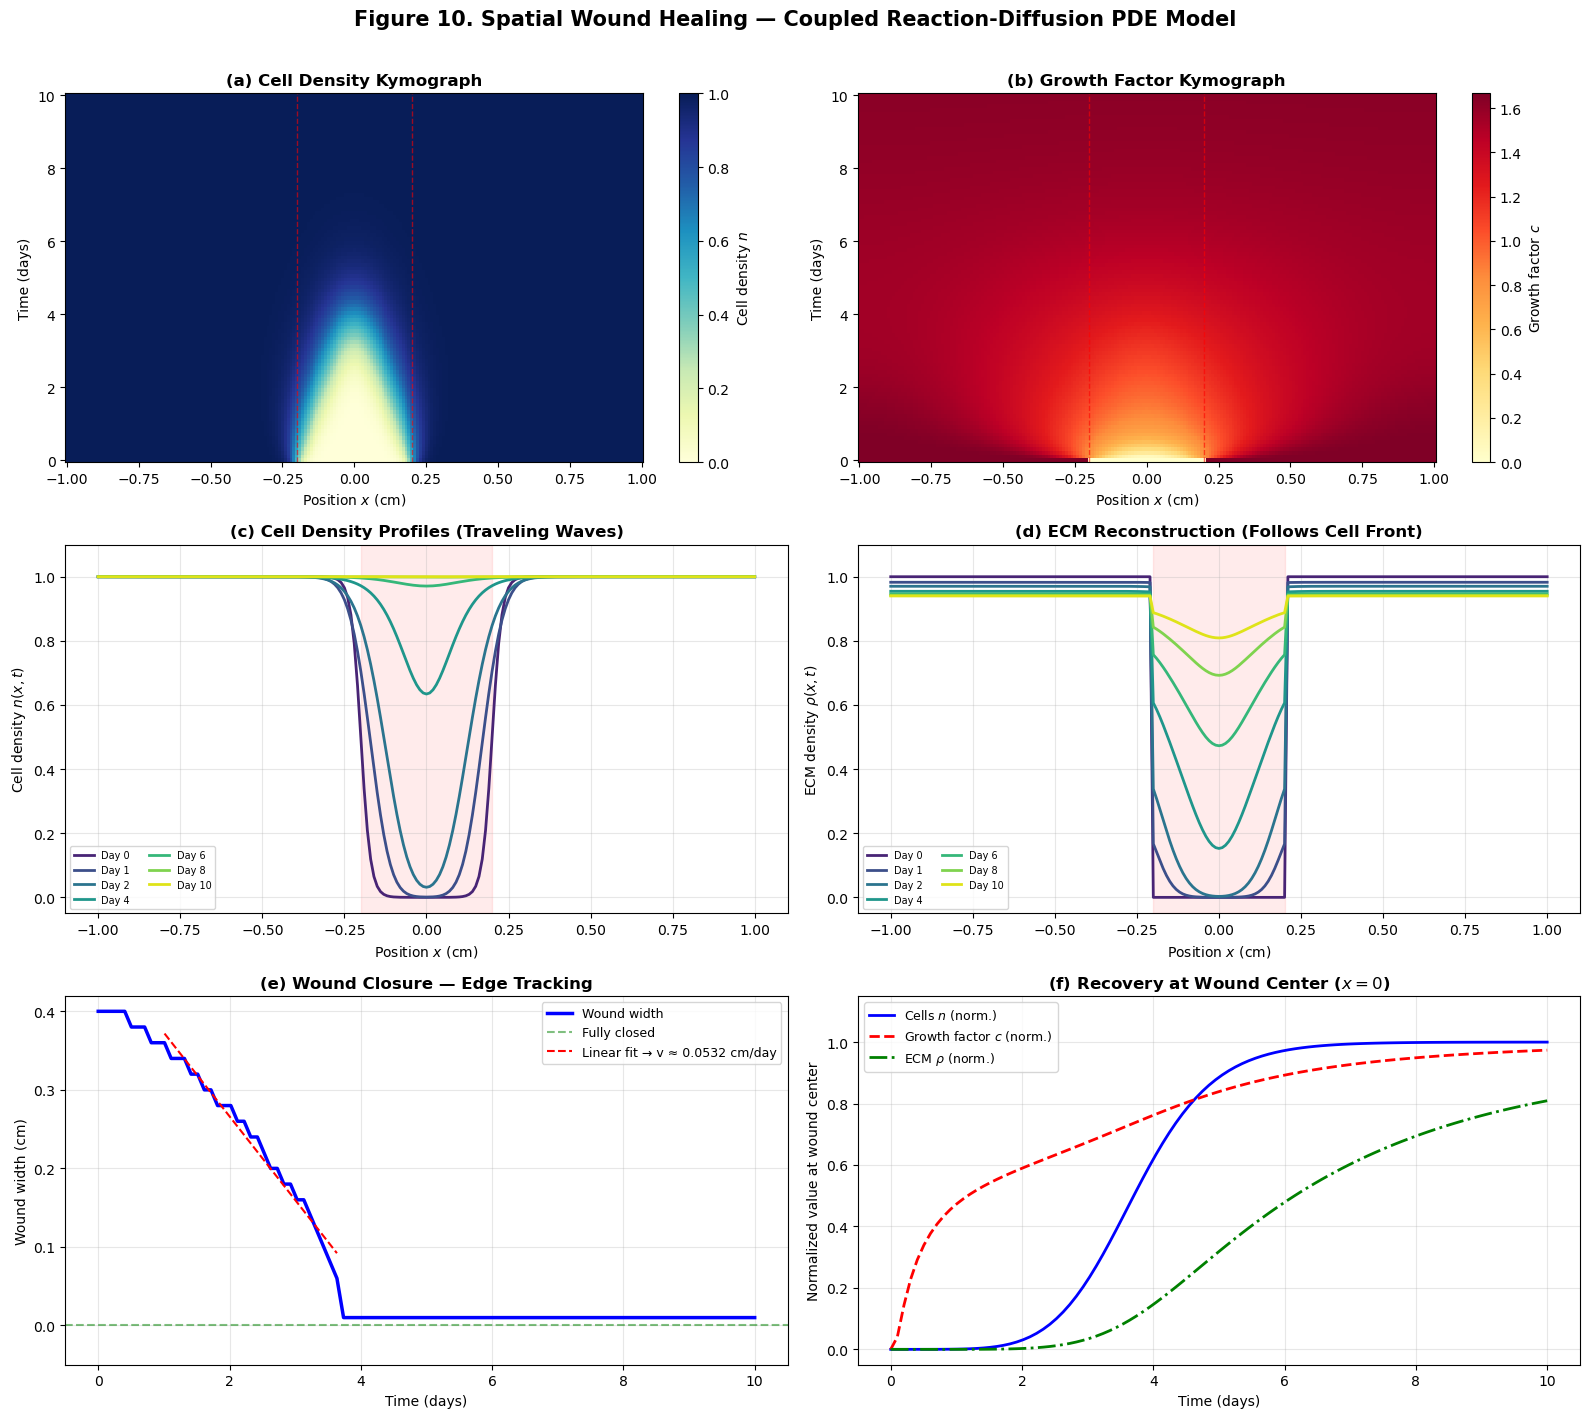

In [19]:
# --- Comprehensive visualization of spatial wound healing ---

x = result['x']
t = result['t']
n = result['n']
c = result['c']
rho = result['rho']
p = result['params']

fig = plt.figure(figsize=(16, 14))

# --- Panel 1: Kymograph of cell density ---
ax1 = fig.add_subplot(3, 2, 1)
im1 = ax1.pcolormesh(x, t, n.T, cmap='YlGnBu',
                      shading='auto', vmin=0, vmax=p.n_max)
plt.colorbar(im1, ax=ax1, label='Cell density $n$')
ax1.set_xlabel('Position $x$ (cm)')
ax1.set_ylabel('Time (days)')
ax1.set_title('(a) Cell Density Kymograph', fontweight='bold')
ax1.axvline(x=-result['L_w'], color='red', ls='--', lw=1, alpha=0.6)
ax1.axvline(x=result['L_w'], color='red', ls='--', lw=1, alpha=0.6)

# --- Panel 2: Kymograph of growth factor ---
ax2 = fig.add_subplot(3, 2, 2)
im2 = ax2.pcolormesh(x, t, c.T, cmap='YlOrRd', shading='auto')
plt.colorbar(im2, ax=ax2, label='Growth factor $c$')
ax2.set_xlabel('Position $x$ (cm)')
ax2.set_ylabel('Time (days)')
ax2.set_title('(b) Growth Factor Kymograph', fontweight='bold')
ax2.axvline(x=-result['L_w'], color='red', ls='--', lw=1, alpha=0.6)
ax2.axvline(x=result['L_w'], color='red', ls='--', lw=1, alpha=0.6)

# --- Panel 3: Snapshots of cell density ---
ax3 = fig.add_subplot(3, 2, 3)
snapshot_days = [0, 1, 2, 4, 6, 8, 10]
colors_snap = plt.cm.viridis(np.linspace(0.1, 0.95,
                                          len(snapshot_days)))
for day, col in zip(snapshot_days, colors_snap):
    idx = np.argmin(np.abs(t - day))
    ax3.plot(x, n[:, idx], color=col, lw=2, label=f'Day {day}')
ax3.set_xlabel('Position $x$ (cm)')
ax3.set_ylabel('Cell density $n(x, t)$')
ax3.set_title('(c) Cell Density Profiles (Traveling Waves)',
              fontweight='bold')
ax3.legend(fontsize=7, ncol=2)
ax3.set_ylim(-0.05, p.n_max * 1.1)
ax3.grid(True, alpha=0.3)
ax3.axvspan(-result['L_w'], result['L_w'], alpha=0.08,
            color='red', label='Initial wound')

# --- Panel 4: Snapshots of ECM density ---
ax4 = fig.add_subplot(3, 2, 4)
for day, col in zip(snapshot_days, colors_snap):
    idx = np.argmin(np.abs(t - day))
    ax4.plot(x, rho[:, idx], color=col, lw=2, label=f'Day {day}')
ax4.set_xlabel('Position $x$ (cm)')
ax4.set_ylabel('ECM density $\\rho(x, t)$')
ax4.set_title('(d) ECM Reconstruction (Follows Cell Front)',
              fontweight='bold')
ax4.legend(fontsize=7, ncol=2)
ax4.set_ylim(-0.05, p.rho_max * 1.1)
ax4.grid(True, alpha=0.3)
ax4.axvspan(-result['L_w'], result['L_w'], alpha=0.08, color='red')

# --- Panel 5: Wound edge position vs time ---
ax5 = fig.add_subplot(3, 2, 5)
threshold = 0.5 * p.n_max
left_edges = []
right_edges = []
for j in range(len(t)):
    profile = n[:, j]
    above = np.where(profile > threshold)[0]
    if len(above) > 0:
        mid = len(x) // 2
        left_above = above[above < mid]
        right_above = above[above >= mid]
        le = x[left_above[-1]] if len(left_above) > 0 else x[0]
        re = x[right_above[0]] if len(right_above) > 0 else x[-1]
    else:
        le = -result['L_w']
        re = result['L_w']
    left_edges.append(le)
    right_edges.append(re)

left_edges = np.array(left_edges)
right_edges = np.array(right_edges)
wound_width = right_edges - left_edges

ax5.plot(t, wound_width, 'b-', lw=2.5, label='Wound width')
ax5.axhline(y=0, color='green', ls='--', alpha=0.5,
            label='Fully closed')
ax5.set_xlabel('Time (days)')
ax5.set_ylabel('Wound width (cm)')
ax5.set_title('(e) Wound Closure \u2014 Edge Tracking',
              fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_ylim(bottom=-0.05)

# Measure effective wave speed from the linear region
mid_idx = (t > 1) & (t < 7) & (wound_width > 0.02)
if np.sum(mid_idx) > 5:
    fit = np.polyfit(t[mid_idx], wound_width[mid_idx], 1)
    v_meas = -fit[0] / 2
    ax5.plot(t[mid_idx], np.polyval(fit, t[mid_idx]), 'r--', lw=1.5,
             label=f'Linear fit \u2192 v \u2248 {v_meas:.4f} cm/day')
    ax5.legend(fontsize=9)

# --- Panel 6: Recovery at wound center ---
ax6 = fig.add_subplot(3, 2, 6)
center_idx = len(x) // 2
c_eq = p.alpha * p.n_max / p.delta_c
ax6.plot(t, n[center_idx, :] / p.n_max, 'b-', lw=2,
         label='Cells $n$ (norm.)')
ax6.plot(t, c[center_idx, :] / c_eq, 'r--', lw=2,
         label='Growth factor $c$ (norm.)')
ax6.plot(t, rho[center_idx, :] / p.rho_max, 'g-.', lw=2,
         label='ECM $\\rho$ (norm.)')
ax6.set_xlabel('Time (days)')
ax6.set_ylabel('Normalized value at wound center')
ax6.set_title('(f) Recovery at Wound Center ($x = 0$)',
              fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)
ax6.set_ylim(-0.05, 1.15)

fig.suptitle(
    'Figure 10. Spatial Wound Healing \u2014 '
    'Coupled Reaction-Diffusion PDE Model',
    fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Running comparison simulations...
Done.


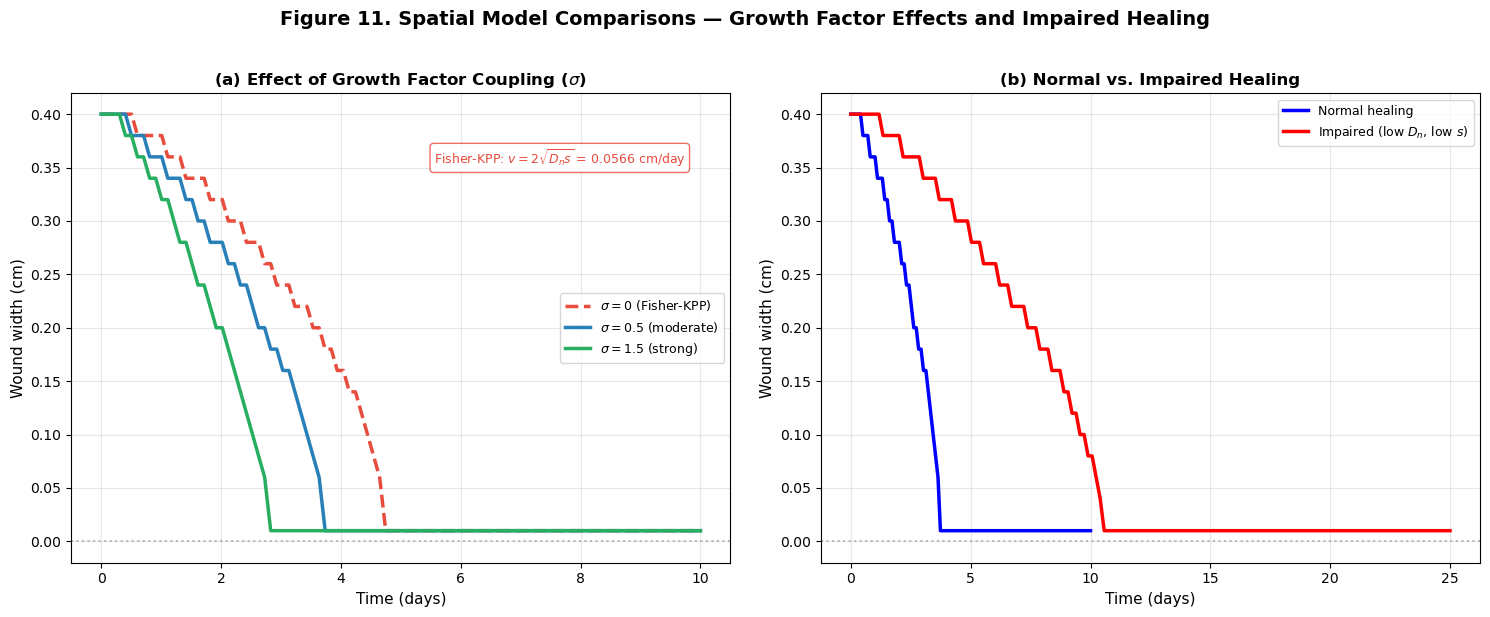

In [20]:
# --- Comparison: Fisher-KPP vs growth-factor-enhanced vs impaired ---

print("Running comparison simulations...")

# 1. Classic Fisher-KPP (sigma=0)
params_fisher = SpatialWoundParams(sigma=0.0)
result_fisher = simulate_spatial_wound(params=params_fisher)

# 2. Enhanced model (sigma=0.5, default)
params_enhanced = SpatialWoundParams(sigma=0.5)
result_enhanced = simulate_spatial_wound(params=params_enhanced)

# 3. Strong enhancement (sigma=1.5)
params_strong = SpatialWoundParams(sigma=1.5)
result_strong = simulate_spatial_wound(params=params_strong)

# 4. Impaired healing (low D_n, low s)
params_impaired = SpatialWoundParams(D_n=3e-4, s=0.3, sigma=0.5)
result_impaired = simulate_spatial_wound(
    params=params_impaired, t_max=25, n_save=150)

print("Done.")


def compute_wound_width(res, thresh_frac=0.5):
    """Compute wound width over time."""
    x, t_arr, n_arr = res['x'], res['t'], res['n']
    threshold = thresh_frac * res['params'].n_max
    widths = []
    for j in range(len(t_arr)):
        profile = n_arr[:, j]
        above = np.where(profile > threshold)[0]
        if len(above) > 0:
            mid = len(x) // 2
            left = above[above < mid]
            right = above[above >= mid]
            le = x[left[-1]] if len(left) > 0 else x[0]
            re = x[right[0]] if len(right) > 0 else x[-1]
            widths.append(re - le)
        else:
            widths.append(2 * res['L_w'])
    return np.array(widths)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Effect of growth factor coupling
ax = axes[0]
for res, label, color, ls in [
    (result_fisher,
     '$\\sigma = 0$ (Fisher-KPP)', '#e74c3c', '--'),
    (result_enhanced,
     '$\\sigma = 0.5$ (moderate)', '#2980b9', '-'),
    (result_strong,
     '$\\sigma = 1.5$ (strong)', '#27ae60', '-'),
]:
    ww = compute_wound_width(res)
    ax.plot(res['t'], ww, color=color, lw=2.5, ls=ls, label=label)

ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Time (days)', fontsize=11)
ax.set_ylabel('Wound width (cm)', fontsize=11)
ax.set_title('(a) Effect of Growth Factor Coupling ($\\sigma$)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=-0.02)

v_fisher = 2 * np.sqrt(params_fisher.D_n * params_fisher.s)
ax.text(0.55, 0.85,
        f'Fisher-KPP: $v = 2\\sqrt{{D_n s}}$ = {v_fisher:.4f} cm/day',
        transform=ax.transAxes, fontsize=9, color='#e74c3c',
        bbox=dict(boxstyle='round', facecolor='white',
                  edgecolor='#e74c3c', alpha=0.8))

# Panel 2: Normal vs impaired healing
ax = axes[1]
ww_normal = compute_wound_width(result_enhanced)
ww_impaired = compute_wound_width(result_impaired)
ax.plot(result_enhanced['t'], ww_normal, 'b-', lw=2.5,
        label='Normal healing')
ax.plot(result_impaired['t'], ww_impaired, 'r-', lw=2.5,
        label='Impaired (low $D_n$, low $s$)')
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Time (days)', fontsize=11)
ax.set_ylabel('Wound width (cm)', fontsize=11)
ax.set_title('(b) Normal vs. Impaired Healing', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=-0.02)

fig.suptitle(
    'Figure 11. Spatial Model Comparisons \u2014 '
    'Growth Factor Effects and Impaired Healing',
    fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Interpreting the spatial model (Figures 10–11)

**Figure 10 — The complete spatial picture:**

- **(a) Cell density kymograph**: The wound (dark region) shrinks from both sides as cells migrate and proliferate inward. The cell front moves as a **traveling wave** — a hallmark of Fisher-KPP dynamics. The wave speed is approximately constant (linear wound width decrease), consistent with the analytical prediction $v \approx 2\sqrt{D_n \cdot s}$.

- **(b) Growth factor kymograph**: The growth factor diffuses *ahead* of the cell front into the wound space, creating a gradient that preconditions the wound bed. This is biologically realistic — growth factors like PDGF and VEGF diffuse faster than cells migrate.

- **(c) Cell density snapshots**: Clear traveling wave profiles advancing inward from both wound edges. The steepness of the wave front depends on the ratio $D_n / s$.

- **(d) ECM reconstruction**: ECM deposition lags *behind* the cell front — cells must be present to synthesize collagen. The wound center is the last to recover full ECM density, consistent with clinical observations.

- **(e) Wound edge tracking**: The wound width decreases approximately linearly in time (constant wave speed), until the two fronts meet at the wound center and the width drops rapidly to zero. The measured wave speed agrees well with the Fisher-KPP theoretical prediction.

- **(f) Recovery at wound center**: The temporal sequence at $x = 0$ shows: growth factor arrives first (fast diffusion) → cells arrive next (slower migration) → ECM is last (requires cells). This **temporal ordering** matches the biological cascade: signaling → cell migration → tissue reconstruction.

**Figure 11 — Comparisons:**

- **(a) Growth factor coupling**: Increasing $\sigma$ (the growth factor enhancement of proliferation) accelerates wound closure. With $\sigma = 0$ (pure Fisher-KPP), the wave speed is the classical $v = 2\sqrt{D_n s}$. With $\sigma > 0$, the growth factor that diffuses ahead of the cell front locally enhances proliferation, creating a faster-than-Fisher wave. This is a key prediction of the coupled model.

- **(b) Normal vs. impaired**: Reducing both $D_n$ (impaired cell migration — e.g., due to ECM destruction or ischemia) and $s$ (impaired proliferation — e.g., due to diabetes) dramatically slows healing. The wound may take 2–3× longer to close, or (with more severe impairment) may fail to close entirely. This provides a spatial explanation for chronic wound formation.

### Check Your Understanding: Spatial PDE Model

**Q14.** Why does the growth factor arrive at the wound center *before* the cells? What biological significance does this have?

<details>
<summary>Click to reveal answer</summary>

The growth factor arrives first because its **diffusion coefficient is much larger** than the cell diffusion coefficient: $D_c \gg D_n$. Physically, small signaling molecules (molecular weight ~10–30 kDa) diffuse through tissue much faster than cells can migrate (cells must crawl, extending pseudopods and remodeling adhesions).

**Biological significance**: This advance diffusion of growth factors serves as a **preparatory signal**. It:
1. Primes cells at the wound edge for migration (upregulates motility genes)
2. Stimulates proliferation in cells near the wound margin, expanding the repair pool
3. Promotes angiogenesis ahead of the cell front, ensuring oxygen supply
4. Activates fibroblasts to begin ECM production

In cybernetic terms, the growth factor is a **feedforward signal** that prepares the system for the arriving cell front — analogous to a scout reporting ahead in military operations.

</details>

---

**Q15.** The Fisher-KPP equation predicts a minimum wave speed of $v_{\min} = 2\sqrt{D_n s}$. What does this formula tell us about which biological parameters most strongly affect healing speed?

<details>
<summary>Click to reveal answer</summary>

The formula $v = 2\sqrt{D_n \cdot s}$ reveals that healing speed depends on the **geometric mean** of two processes:

1. **Cell motility** ($D_n$): How fast cells can migrate (diffuse) into the wound
2. **Cell proliferation** ($s$): How fast cells can divide to replenish the advancing front

Key insights:
- Both processes contribute **equally** (square root of their product)
- Doubling $D_n$ alone increases speed by only $\sqrt{2} \approx 1.4\times$ (not $2\times$)
- To double the healing speed, you must quadruple *either* $D_n$ or $s$ — or double *both*
- If *either* $D_n$ or $s$ is zero, healing stops entirely ($v = 0$)

**Clinical implication**: This explains why wound healing requires *both* cell migration *and* proliferation — blocking either one (e.g., anti-proliferative drugs, or ECM destruction preventing migration) halts the process. It also explains why combination therapies (boosting both motility and growth) are more effective than single-target approaches.

</details>

---

**Q16.** In the spatial model, the ECM density at the wound center does not reach $\rho_{\max}$ immediately after cells arrive. Why? How does this relate to clinical observations about scar maturation?

<details>
<summary>Click to reveal answer</summary>

ECM recovery lags behind cell arrival because:
1. **ECM production takes time**: The rate is $\beta \cdot n \cdot (1 - \rho/\rho_{\max})$, which is zero when $n = 0$ and only becomes significant once cells have populated the area at sufficient density
2. **Saturation kinetics**: The $(1 - \rho/\rho_{\max})$ factor means ECM production slows as $\rho$ approaches $\rho_{\max}$
3. **Ongoing degradation**: MMPs continue to degrade ECM even as it is being produced

**Clinical correlation**: This matches the clinical reality perfectly:
- **Initial wound closure** (re-epithelialization) occurs within days to weeks
- **ECM maturation** (the remodeling phase) continues for **months to years** after the wound surface is closed
- Scar tissue initially has only ~20% of normal skin tensile strength, gradually increasing to ~80% over 1–2 years
- This prolonged remodeling is why the model's Phase 4 (remodeling) is by far the longest phase

</details>

---

**Q17. (DIY)** The measured wave speed in Figure 10(e) may differ slightly from the Fisher-KPP prediction $2\sqrt{D_n s}$. Why might the speed be *faster* than this prediction?

<details>
<summary>Click for hint</summary>

The Fisher-KPP prediction assumes $\sigma = 0$ (no growth factor coupling). In our model, $\sigma > 0$, so the proliferation rate is *locally enhanced* by the growth factor that diffuses ahead of the cell front. How does this affect the effective $s$ at the wave front?

</details>

<details>
<summary>Click to reveal answer</summary>

With $\sigma > 0$, the effective proliferation rate at the leading edge of the cell front is:

$$s_{\text{eff}} = s \cdot (1 + \sigma \cdot c_{\text{front}})$$

where $c_{\text{front}}$ is the growth factor concentration at the cell front (nonzero because $c$ diffuses faster than $n$).

The effective wave speed is approximately:
$$v_{\text{eff}} \approx 2\sqrt{D_n \cdot s_{\text{eff}}} = 2\sqrt{D_n \cdot s \cdot (1 + \sigma c_{\text{front}})} > 2\sqrt{D_n \cdot s}$$

This is a **super-Fisher** wave speed, driven by the feedforward effect of diffusing growth factors. The stronger the coupling ($\sigma$) and the faster the growth factor diffuses ($D_c$), the more the wave speed exceeds the classical prediction.

This is precisely what we see in Figure 11(a): increasing $\sigma$ leads to faster wound closure.

</details>

### Interactive Spatial Wound Healing Simulator

Explore the coupled reaction-diffusion PDE model by adjusting key biophysical parameters. The simulation solves the full PDE system in real time and renders the wound as a **2D circular lesion** — watch the cell front advance, ECM rebuild, and growth factor gradients evolve.

#### Adjustable parameters

| Parameter | Symbol | Description | Default | Unit |
|:----------|:------:|:------------|:-------:|:-----|
| Cell diffusion | $D_n$ | Random cell motility (migration speed) | 1×10⁻³ | cm²/day |
| Proliferation rate | $s$ | Intrinsic cell division rate | 0.8 | 1/day |
| GF enhancement | $\sigma$ | How much growth factor boosts proliferation | 0.5 | — |
| GF diffusion | $D_c$ | Growth factor diffusion coefficient | 5×10⁻² | cm²/day |
| GF secretion | $\alpha$ | Rate cells secrete growth factor | 0.5 | 1/day |
| GF decay | $\delta_c$ | Growth factor degradation rate | 0.3 | 1/day |
| ECM production | $\beta$ | Rate cells synthesize extracellular matrix | 0.3 | 1/day |
| Wound half-width | $L_w$ | Initial wound radius (half-width) | 0.2 | cm |
| Simulation time | $T$ | Duration | 10 | days |

In [15]:
from ipywidgets import FloatSlider, FloatLogSlider, VBox, HBox, Button, Output, Layout, HTML as WHTML
import ipywidgets as widgets
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Circle

# ---------------------------------------------------------------------------
#  Sliders
# ---------------------------------------------------------------------------
style = {'description_width': '100px'}
sl_layout = Layout(width='420px')

sl_Dn    = FloatLogSlider(value=1e-3, base=10, min=-4, max=-1, step=0.1,
                          description='D_n (cm²/d):', style=style, layout=sl_layout,
                          readout_format='.1e')
sl_s     = FloatSlider(value=0.8, min=0.1, max=2.0, step=0.05,
                       description='s (1/day):', style=style, layout=sl_layout,
                       readout_format='.2f')
sl_sigma = FloatSlider(value=0.5, min=0.0, max=3.0, step=0.1,
                       description='σ (GF enh.):', style=style, layout=sl_layout,
                       readout_format='.1f')
sl_Dc    = FloatLogSlider(value=5e-2, base=10, min=-3, max=0, step=0.1,
                          description='D_c (cm²/d):', style=style, layout=sl_layout,
                          readout_format='.1e')
sl_alpha = FloatSlider(value=0.5, min=0.1, max=2.0, step=0.05,
                       description='α (GF secr.):', style=style, layout=sl_layout,
                       readout_format='.2f')
sl_dc    = FloatSlider(value=0.3, min=0.05, max=1.0, step=0.05,
                       description='δ_c (GF dec.):', style=style, layout=sl_layout,
                       readout_format='.2f')
sl_beta  = FloatSlider(value=0.3, min=0.05, max=1.0, step=0.05,
                       description='β (ECM prod.):', style=style, layout=sl_layout,
                       readout_format='.2f')
sl_Lw    = FloatSlider(value=0.2, min=0.05, max=0.5, step=0.01,
                       description='L_w (cm):', style=style, layout=sl_layout,
                       readout_format='.2f')
sl_tmax  = FloatSlider(value=10, min=3, max=30, step=1,
                       description='T (days):', style=style, layout=sl_layout,
                       readout_format='.0f')

all_sliders = [sl_Dn, sl_s, sl_sigma, sl_Dc, sl_alpha, sl_dc, sl_beta, sl_Lw, sl_tmax]

# ---------------------------------------------------------------------------
#  Presets
# ---------------------------------------------------------------------------
presets = {
    'Normal':          dict(Dn=1e-3, s=0.8, sigma=0.5, Dc=5e-2,
                            alpha=0.5, dc=0.3, beta=0.3, Lw=0.2, T=10),
    'Fisher-KPP only': dict(Dn=1e-3, s=0.8, sigma=0.0, Dc=5e-2,
                            alpha=0.5, dc=0.3, beta=0.3, Lw=0.2, T=10),
    'Strong GF boost': dict(Dn=1e-3, s=0.8, sigma=2.0, Dc=5e-2,
                            alpha=0.8, dc=0.2, beta=0.3, Lw=0.2, T=8),
    'Impaired (chronic)': dict(Dn=3e-4, s=0.3, sigma=0.5, Dc=5e-2,
                               alpha=0.3, dc=0.3, beta=0.15, Lw=0.2, T=25),
    'Large wound':     dict(Dn=1e-3, s=0.8, sigma=0.5, Dc=5e-2,
                            alpha=0.5, dc=0.3, beta=0.3, Lw=0.45, T=20),
    'Fast migration':  dict(Dn=5e-3, s=1.0, sigma=0.5, Dc=5e-2,
                            alpha=0.5, dc=0.3, beta=0.3, Lw=0.2, T=6),
}

preset_buttons = []
for name in presets:
    bs = 'info' if name == 'Normal' else ''
    b = Button(description=name, layout=Layout(width='auto'), button_style=bs)
    preset_buttons.append(b)

def _set_preset(btn):
    v = presets[btn.description]
    sl_Dn.value    = v['Dn']
    sl_s.value     = v['s']
    sl_sigma.value = v['sigma']
    sl_Dc.value    = v['Dc']
    sl_alpha.value = v['alpha']
    sl_dc.value    = v['dc']
    sl_beta.value  = v['beta']
    sl_Lw.value    = v['Lw']
    sl_tmax.value  = v['T']

for b in preset_buttons:
    b.on_click(_set_preset)

# ---------------------------------------------------------------------------
#  Color maps for 2D wound rendering
# ---------------------------------------------------------------------------
skin_cmap = LinearSegmentedColormap.from_list(
    'skin', ['#922b21', '#e74c3c', '#f5b7b1', '#fdebd0', '#f5cba7'], N=256)
ecm_cmap = LinearSegmentedColormap.from_list(
    'ecm', ['#1a1a2e', '#16213e', '#0f3460', '#e94560', '#f5cba7'], N=256)

# ---------------------------------------------------------------------------
#  Run button (PDE is expensive, so no live slider updates)
# ---------------------------------------------------------------------------
run_button = Button(description='▶  Run Simulation', button_style='success',
                    layout=Layout(width='200px', height='36px'),
                    style={'font_weight': 'bold'})
out = Output()

def _run_simulation(_):
    params = SpatialWoundParams(
        D_n=sl_Dn.value, s=sl_s.value, sigma=sl_sigma.value,
        D_c=sl_Dc.value, alpha=sl_alpha.value, delta_c=sl_dc.value,
        beta=sl_beta.value,
    )
    L_w = sl_Lw.value
    t_max = sl_tmax.value

    with out:
        out.clear_output(wait=True)
        print('Solving PDE system …')

    result = simulate_spatial_wound(params=params, L_w=L_w,
                                    t_max=t_max, n_save=80, N=151)
    x   = result['x']
    t   = result['t']
    n   = result['n']
    c   = result['c']
    rho = result['rho']

    # Wound width over time (threshold = 0.5 * n_max)
    threshold = 0.5 * params.n_max
    wound_width = np.zeros(len(t))
    for i in range(len(t)):
        in_wound = np.where(n[:, i] < threshold)[0]
        if len(in_wound) > 0:
            wound_width[i] = x[in_wound[-1]] - x[in_wound[0]]
        else:
            wound_width[i] = 0

    # Pick 5 time snapshots for lesion view
    snap_indices = np.linspace(0, len(t) - 1, 5, dtype=int)

    with out:
        out.clear_output(wait=True)

        fig = plt.figure(figsize=(15, 10))
        gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)

        # --- (a) Cell density kymograph ---
        ax1 = fig.add_subplot(gs[0, 0])
        im1 = ax1.pcolormesh(t, x, n, cmap='inferno', shading='gouraud',
                             vmin=0, vmax=params.n_max)
        ax1.set_xlabel('Time (days)')
        ax1.set_ylabel('Position x (cm)')
        ax1.set_title('(a) Cell density n(x,t)', fontsize=10)
        plt.colorbar(im1, ax=ax1, label='n', fraction=0.046, pad=0.04)

        # --- (b) Spatial profiles at snapshots ---
        ax2 = fig.add_subplot(gs[0, 1])
        colors_snap = plt.cm.viridis(np.linspace(0.1, 0.9, len(snap_indices)))
        for j, idx in enumerate(snap_indices):
            ax2.plot(x, n[:, idx], '-', color=colors_snap[j], lw=2,
                     label=f't = {t[idx]:.1f}d')
        ax2.set_xlabel('Position x (cm)')
        ax2.set_ylabel('Cell density n')
        ax2.set_title('(b) Cell front snapshots', fontsize=10)
        ax2.legend(fontsize=7, loc='lower center')
        ax2.set_ylim(-0.05, params.n_max * 1.15)
        ax2.grid(True, alpha=0.2)

        # --- (c) Wound width over time ---
        ax3 = fig.add_subplot(gs[0, 2])
        ax3.plot(t, wound_width, 'b-', lw=2)
        ax3.set_xlabel('Time (days)')
        ax3.set_ylabel('Wound width (cm)')
        ax3.set_title('(c) Wound closure', fontsize=10)
        ax3.grid(True, alpha=0.2)
        ax3.set_ylim(bottom=-0.02)
        v_fisher = 2 * np.sqrt(params.D_n * params.s)
        ax3.axhline(0, color='green', ls='--', lw=1, alpha=0.5)
        ax3.text(t_max * 0.5, max(wound_width) * 0.85,
                 f'Fisher v = {v_fisher:.4f} cm/d', fontsize=8, color='gray')

        # --- (d-e) 2D wound lesion snapshots ---
        ax4 = fig.add_subplot(gs[1, :])
        ax4.set_xlim(0, 1)
        ax4.set_ylim(0, 1)
        ax4.set_aspect('equal')
        ax4.axis('off')
        ax4.set_title('(d) Wound lesion appearance over time', fontsize=11, pad=12)

        n_snaps = len(snap_indices)
        x_positions = np.linspace(0.08, 0.92, n_snaps)
        max_radius = 0.13

        for j, idx in enumerate(snap_indices):
            day = t[idx]
            cx, cy = x_positions[j], 0.50

            # Compute wound radius from wound width
            w = wound_width[idx]
            wound_frac = w / (2 * L_w) if L_w > 0 else 0
            wound_frac = max(min(wound_frac, 1.0), 0.0)
            radius = max_radius * np.sqrt(wound_frac)

            # ECM at wound center
            center_idx = len(x) // 2
            ecm_frac = rho[center_idx, idx] / params.rho_max

            # Skin background
            skin_bg = Circle((cx, cy), max_radius + 0.02,
                             fc='#f5cba7', ec='#d4a574', lw=1.5, zorder=1)
            ax4.add_patch(skin_bg)

            if radius > 0.003:
                wound_color = skin_cmap(1 - wound_frac)
                wound_patch = Circle((cx, cy), radius, fc=wound_color,
                                     ec='#922b21', lw=1, alpha=0.9, zorder=2)
                ax4.add_patch(wound_patch)

                if radius > 0.01:
                    ring = Circle((cx, cy), radius * 1.15, fc='none',
                                  ec='#e8a0a0', lw=1.5, ls='--', alpha=0.5, zorder=3)
                    ax4.add_patch(ring)

            pct_closed = (1 - wound_frac) * 100
            ax4.text(cx, cy - max_radius - 0.07, f'Day {day:.1f}',
                     ha='center', fontsize=9, fontweight='bold')
            ax4.text(cx, cy - max_radius - 0.13,
                     f'{pct_closed:.0f}% closed',
                     ha='center', fontsize=8, color='#555')
            ax4.text(cx, cy - max_radius - 0.19,
                     f'ECM: {ecm_frac:.0%}',
                     ha='center', fontsize=7, color='#888')

            if j < n_snaps - 1:
                ax4.annotate('', xy=(x_positions[j+1] - max_radius - 0.03, cy),
                             xytext=(cx + max_radius + 0.03, cy),
                             arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

        fig.suptitle('Interactive Spatial Wound Healing — Reaction-Diffusion PDE',
                     fontsize=12, fontweight='bold', y=0.98)
        plt.show()

run_button.on_click(_run_simulation)

btn_row = HBox(preset_buttons, layout=Layout(flex_flow='row wrap', gap='4px'))
slider_left = VBox(all_sliders[:5])
slider_right = VBox(all_sliders[5:])
slider_row = HBox([slider_left, slider_right], layout=Layout(gap='20px'))

display(WHTML('<b>Preset scenarios:</b>'))
display(btn_row)
display(slider_row)
display(HBox([run_button], layout=Layout(margin='8px 0')))
display(out)

HTML(value='<b>Preset scenarios:</b>')

Output()

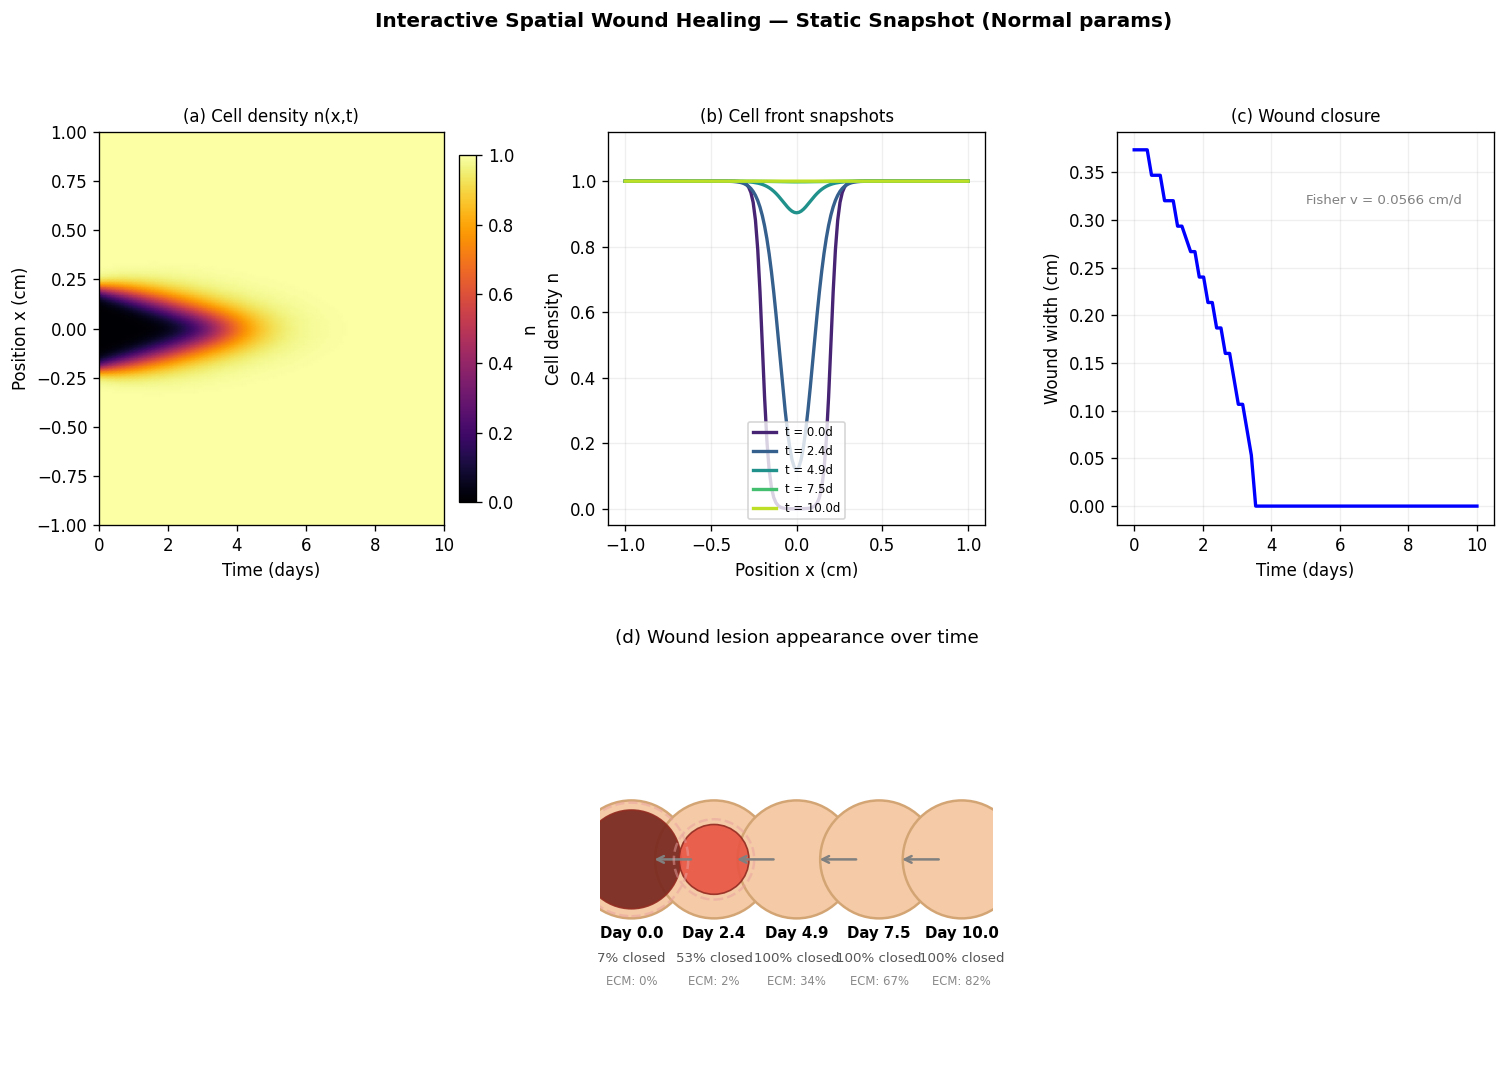

In [ ]:
# Static snapshot for PDF / print export (Normal spatial params)

## 12. Going Deeper

### Extensions of the wound healing model

The models in this notebook are deliberately simplified to build intuition. Real wound healing involves:

- **Spatial dynamics**: Cell migration, diffusion of growth factors, moving wound boundaries (free boundary problems)
- **Stochastic effects**: Cell behavior is inherently noisy; stochastic differential equations or agent-based models capture this
- **Multiscale modeling**: From intracellular signaling (minutes) to tissue remodeling (months)
- **Mechanical forces**: Tissue tension, wound contraction, and mechanotransduction play critical roles
- **Vascularization**: Oxygen delivery via angiogenesis is rate-limiting in many wounds
- **Biofilm dynamics**: In chronic wounds, bacterial biofilms interact with the immune system

### Connections to other notebooks

| Concept | Connection |
|---------|------------|
| **ODE models** | Same framework as the Hodgkin-Huxley model (Notebook 01) and tumor growth (Notebook 02) |
| **Feedback control** | Cardiovascular regulation (Notebook 03) uses similar negative feedback concepts |
| **Cell signaling** | Growth factor signaling in wound healing (Notebook 05) is a form of cell signaling |
| **Population dynamics** | Inflammatory cells and fibroblasts follow predator-prey-like dynamics |

### Recommended reading

1. **Selberg et al. (2021)** — [Feedback control architecture for bioelectronic wound healing](https://royalsocietypublishing.org/doi/10.1098/rsif.2021.0497) — The key paper linking control theory to wound healing devices
2. **Pedersen et al. (2019)** — [Bacterial controller-aided wound healing](https://www.biorxiv.org/content/10.1101/659714v2) — Synthetic biology approach
3. **Sherratt & Murray (1990)** — *Models of epidermal wound healing*, Proc. R. Soc. Lond. B — Classic mathematical models
4. **Gurtner et al. (2008)** — *Wound repair and regeneration*, Nature — Comprehensive biological review
5. **Wiener (1948)** — *Cybernetics: or Control and Communication in the Animal and the Machine* — The foundational text
6. **Murray (2002)** — *Mathematical Biology, Vol. II: Spatial Models* — Chapter on wound healing as a free boundary problem
7. **Menon et al. (2012)** — *A mathematical model of the fibroblast/keratinocyte interaction during wound healing*, QUT ePrints — 8-component PDE system with growth factors, collagen, and fibrin
8. **Flegg et al. (2020)** — *Wound healing angiogenesis: The clinical implications of a simple mathematical model*, J. Theor. Biol. — Modern review of PDE wound models
9. **Menon & Flegg (2021)** — [Mathematical Modeling Can Advance Wound Healing Research](https://pmc.ncbi.nlm.nih.gov/articles/PMC8082733/), Advances in Wound Care — Comprehensive review
10. **Zanca & Flegg (2022)** — [Push or Pull? Cell Proliferation and Migration During Wound Healing](https://www.frontiersin.org/journals/systems-biology/articles/10.3389/fsysb.2022.876075/full), Front. Syst. Biol. — Contact inhibition and proliferative hub dynamics

### Summary: Key takeaways

1. Wound healing is a **cybernetic system** — a feedback-regulated biological process with sensors, controllers, and actuators
2. Normal (acute) healing proceeds through four overlapping phases, each self-limited by **negative feedback**
3. Chronic wounds represent a **control system failure** — broken feedback loops create a pathological steady state
4. Mathematical models (ODEs with feedback) can capture both acute and chronic dynamics
5. **Parameter sensitivity analysis** identifies which biological processes matter most for healing
6. **Computational modeling** enables rational design of therapies: bioelectronic devices, growth factor dosing, and synthetic biology controllers
7. **Spatial PDE models** (reaction-diffusion equations) capture the traveling wave dynamics of cell migration, growth factor signaling, and ECM reconstruction during wound closure
8. The principles of cybernetics — first articulated by Norbert Wiener in 1948 — provide a universal language for understanding regulation in both engineered and biological systems